# PRÁCTICA MACHINE LEARNING

## Graph Classification with Graph Neural Networks. Dataset: COLLAB

Profesor: Francisco Escolano

Alumno: Nicolás Vives Vicente

La tarea más común para la clasificación de grafos es la **predicción de propiedades moleculares**, en la que las moléculas se representan como grafos, y la tarea puede consistir en inferir si una molécula inhibe la replicación del virus del VIH o no.

La Universidad Técnica de Dortmund ha recopilado una amplia gama de diferentes conjuntos de datos de clasificación de grafos, conocidos como [**TUDatasets**](https://chrsmrrs.github.io/datasets/), los cuales también son accesibles a través de [`torch_geometric.datasets.TUDataset`](https://pytorch-geometric.readthedocs.io/en/latest/modules/datasets.html#torch_geometric.datasets.TUDataset) en PyTorch Geometric.

En este notebook se estudia el **conjunto de datos COLLAB**:

## Librerías necesarias:

In [1]:
# Install PyTorch Geometric
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 44.3 MB/s eta 0:00:00


In [2]:
# Librerías Estándar de Python
import os
import csv
import random
from collections import Counter

# Análisis de Datos, Grafos y Visualización
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# PyTorch
import torch
import torch.nn.functional as F
from torch.nn import Linear

# PyTorch Geometric (Utilidades)
import torch_geometric.data
from torch_geometric.utils import degree
import torch_geometric.transforms as T
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_networkx, to_dense_batch, to_dense_adj

# PyTorch Geometric (Capas GNN y Pooling)
from torch_geometric.nn import GCNConv
from torch_geometric.nn import global_mean_pool  # Global Mean Pooling
from torch_geometric.nn import global_add_pool   # Global Add Pooling
from torch_geometric.nn import global_max_pool   # Global Max Pooling

# Modelo Net
from torch_geometric.nn import dense_mincut_pool, DenseGraphConv

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Inspección del dataset:

Este conjunto de datos dispone de 5000 grafos que no caben en google colab por lo que la siguiente celda de inspección se ha ejecutado en local.

El cambio fundamental respecto a los experimentos anteriores es la generación de las características iniciales ya que no dispone de ellas. Por el tamaño que tiene se emplea la transformación `T.LocalDegreeProfile()` de `PyTorch Geometric`. Esta técnica calcula **5 valores estadísticos** eficientes para cada nodo basándose en su vecindario local: su propio grado, así como el mínimo, máximo, media y desviación estándar de los grados de sus vecinos.

In [ ]:
dataset = TUDataset(root='data/TUDataset', name='COLLAB', pre_transform=T.LocalDegreeProfile())

print()
print(f'Dataset: {dataset}:')
print('====================')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

# Extraemos las etiquetas (y) de cada grafo y las contamos
labels = [data.y.item() for data in dataset]
class_counts = Counter(labels)

print('====================')
print('Samples per class:')
for cls, count in sorted(class_counts.items()):
    print(f' - Class {cls}: {count}')
print('====================')

num_nodes_list = [data.num_nodes for data in dataset]

mean_nodes = np.mean(num_nodes_list)
min_nodes = np.min(num_nodes_list)
max_nodes = np.max(num_nodes_list)

print('Node statistics per molecule:')
print(f' - Mean nodes: {mean_nodes:.2f}')
print(f' - Min nodes: {min_nodes}')
print(f' - Max nodes: {max_nodes}')
print('====================')

data = dataset[0]  # Get the first graph object.

print()
print(data)
print('=============================================================')

# Gather some statistics about the first graph.
print(f'Number of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')
print(f'Average node degree: {data.num_edges / data.num_nodes:.2f}')
print(f'Has isolated nodes: {data.has_isolated_nodes()}')
print(f'Has self-loops: {data.has_self_loops()}')
print(f'Is undirected: {data.is_undirected()}')

Processing...
Done!



Dataset: COLLAB(5000):
Number of graphs: 5000
Number of features: 5
Number of classes: 3
Samples per class:
 - Class 0: 2600
 - Class 1: 775
 - Class 2: 1625
Node statistics per molecule:
 - Mean nodes: 74.49
 - Min nodes: 32
 - Max nodes: 492

Data(edge_index=[2, 1980], y=[1], x=[45, 5], num_nodes=45)
Number of nodes: 45
Number of edges: 1980
Average node degree: 44.00
Has isolated nodes: False
Has self-loops: False
Is undirected: True


* **Número total de grafos:** 5000
* **Características de nodo:** 5 (perfil de grado local sintético).
* **Número de clases:** 3
* **Distribución de clases:**
  - Class 0: 2600
  - Class 1: 775
  - Class 2: 1625

**Estadísticas de tamaño por red (grafo):**
* **Media de nodos:** 74.49
* **Rango de nodos:** De 32 (mínimo) a 492 (máximo).

Al analizar el primer objeto del conjunto (`Data(edge_index=[2, 1980], y=[1], x=[45, 5], num_nodes=45)`), extraemos sus propiedades exactas:

* **Composición:** 45 nodos y 1980 aristas, lo que resulta en un grado promedio por nodo de 44.
* **Etiquetas:** Una única etiqueta de clasificación para todo el grafo (`y=[1]`).

Además, el análisis topológico revela propiedades fundamentales sobre la naturaleza de estos hilos de discusión:

* **No dirigido (*Is undirected: True*):** La interacción entre dos usuarios se modela de forma bidireccional.
* **Conectividad total (*Has isolated nodes: False*):** No existen nodos aislados.
* **Sin bucles (*Has self-loops: False*):** No existen conexiones de un usuario consigo mismo.

## *UNDERSAMPLING*

Debido al desbalanceo de clases y a que el conjunto de datos completo no nos cabe en google colab, lo que haremos será tomar 775 muestras de cada clase, exactamente las que se tienen de la clase minoritaria. Esto nos dará un conjunto de datos de 2325 muestras que sí podremos manejar, y que además contará con las clases balanceadas.

In [ ]:
indices_clase_0 = [] # Alta Energía (2600 grafos)
indices_clase_1 = [] # Materia Condensada (1625 grafos)
indices_clase_2 = [] # Astrofísica (775 grafos)

for i, data in enumerate(dataset):
    if data.y.item() == 0:
        indices_clase_0.append(i)
    elif data.y.item() == 1:
        indices_clase_1.append(i)
    elif data.y.item() == 2:
        indices_clase_2.append(i)

# muestrear aleatoriamente 775 grafos de cada clase (con semilla para reproducibilidad)
random.seed(12345)
muestras_por_clase = 775

indices_0_sub = random.sample(indices_clase_0, muestras_por_clase)
indices_1_sub = random.sample(indices_clase_1, muestras_por_clase)
indices_2_sub = random.sample(indices_clase_2, muestras_por_clase) # Coge todos los de la clase 2

# unir todos los índices y desordenarlos para que no queden agrupados por clase
indices_finales = indices_0_sub + indices_1_sub + indices_2_sub
random.shuffle(indices_finales)

# crear la lista final de grafos
dataset_balanceado = [dataset[i] for i in indices_finales]

print(f"Total de grafos: {len(dataset_balanceado)}")

# comprobación de que está perfectamente balanceado
clases_finales = [data.y.item() for data in dataset_balanceado]
print(f"Distribución final -> Clase 0: {clases_finales.count(0)}, Clase 1: {clases_finales.count(1)}, Clase 2: {clases_finales.count(2)}")

# GUARDAR EL DATASET
nombre_archivo = 'COLLAB_balanceado_2325.pt'
torch.save(dataset_balanceado, nombre_archivo)
print(f"\nDataset guardado en el archivo: {nombre_archivo}")

Total de grafos: 2325
Distribución final -> Clase 0: 775, Clase 1: 775, Clase 2: 775

Dataset guardado en el archivo: COLLAB_balanceado_2325.pt


Una vez creado este conjunto de datos reducido en local ya podemos trabajar en google colab y cargarlo desde el archivo drive.

In [4]:
from google.colab import drive

print("Descargando el dataset...")
!gdown --id 1TSM1AX5PxQp_HLaqTKETGv4EP9kIP5hp -O COLLAB_balanceado_2325.pt

dataset = torch.load('/content/COLLAB_balanceado_2325.pt', weights_only=False)
print(f"Cargados {len(dataset)} grafos desde disco.")

print()
print(f'Dataset: {dataset}:')
print('====================')
print(f'Number of graphs: {len(dataset)}')

# Calculate num_features and num_classes from the loaded list of Data objects
# Assuming all graphs have the same number of features
num_features_val = dataset[0].x.shape[1] if hasattr(dataset[0], 'x') and dataset[0].x is not None else 0

# Extract labels to determine number of classes
labels = [data.y.item() for data in dataset]
num_classes_val = len(set(labels)) # Get number of unique classes

print(f'Number of features: {num_features_val}')
print(f'Number of classes: {num_classes_val}')

# Extraemos las etiquetas (y) de cada grafo y las contamos
# labels is already computed above
class_counts = Counter(labels)

print('====================')
print('Samples per class:')
for cls, count in sorted(class_counts.items()):
    print(f' - Class {cls}: {count}')
print('====================')

num_nodes_list = [data.num_nodes for data in dataset]

mean_nodes = np.mean(num_nodes_list)
min_nodes = np.min(num_nodes_list)
max_nodes = np.max(num_nodes_list)

print('Node statistics per molecule:')
print(f' - Mean nodes: {mean_nodes:.2f}')
print(f' - Min nodes: {min_nodes}')
print(f' - Max nodes: {max_nodes}')
print('====================')

data = dataset[0]  # Get the first graph object.

print()
print(data)
print('=============================================================')

# Gather some statistics about the first graph.
print(f'Number of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')
print(f'Average node degree: {data.num_edges / data.num_nodes:.2f}')
print(f'Has isolated nodes: {data.has_isolated_nodes()}')
print(f'Has self-loops: {data.has_self_loops()}')
print(f'Is undirected: {data.is_undirected()}')

Descargando el dataset...
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1TSM1AX5PxQp_HLaqTKETGv4EP9kIP5hp
From (redirected): https://drive.google.com/uc?id=1TSM1AX5PxQp_HLaqTKETGv4EP9kIP5hp&confirm=t&uuid=2716b0dd-fdba-421c-b503-4983b9a7cdc2
To: /content/COLLAB_balanceado_2325.pt
100% 401M/401M [00:07<00:00, 52.5MB/s]
Cargados 2325 grafos desde disco.

Dataset: [Data(edge_index=[2, 990], y=[1], x=[67, 5], num_nodes=67), Data(edge_index=[2, 1916], y=[1], x=[50, 5], num_nodes=50), Data(edge_index=[2, 3854], y=[1], x=[86, 5], num_nodes=86), Data(edge_index=[2, 522], y=[1], x=[36, 5], num_nodes=36), Data(edge_index=[2, 2652], y=[1], x=[52, 5], num_nodes=52), Data(edge_index=[2, 262], y=[1], x=[34, 5], num_nodes=34), Data(edge_index=[2, 412], y=[1], x=[38, 

* **Número total de grafos:** 2325
* **Características de nodo:** 5 (sintéticas)
* **Número de clases:** 3 (clasificación multiclase equilibrada: 775 muestras por clase).
* **Tamaño de las redes:** * **Media:** 72.03 nodos
  * **Rango:** De 32 (mínimo) a 487 (máximo).

Tras el análisis del primer grafo (`Data(edge_index=[2, 990], x=[67, 5], y=[1], num_nodes=67)`) obtenemos la siguiente información:

* **Composición y Densidad:** Cuenta con 67 nodos y 990 aristas, lo que resulta en un grado promedio notablemente alto de **14.78 colaboraciones por autor**.
* **Etiqueta:** Posee una única etiqueta global (`y=[1]`) que indica el subcampo de la física al que pertenece.
* **Topología de la red:**
  * **No dirigido (*Is undirected: True*):** La coautoría es una relación mutua y recíproca.
  * **Conectividad total (*Has isolated nodes: False*):** No hay científicos aislados; todos están integrados en la red principal.
  * **Sin bucles (*Has self-loops: False*):** No se registran conexiones de un autor consigo mismo.

Como tenemos seis 3, veamos un ejemplo de molécula perteneciente a cada una de ellas.

tensor([0])
tensor([1])
tensor([2])


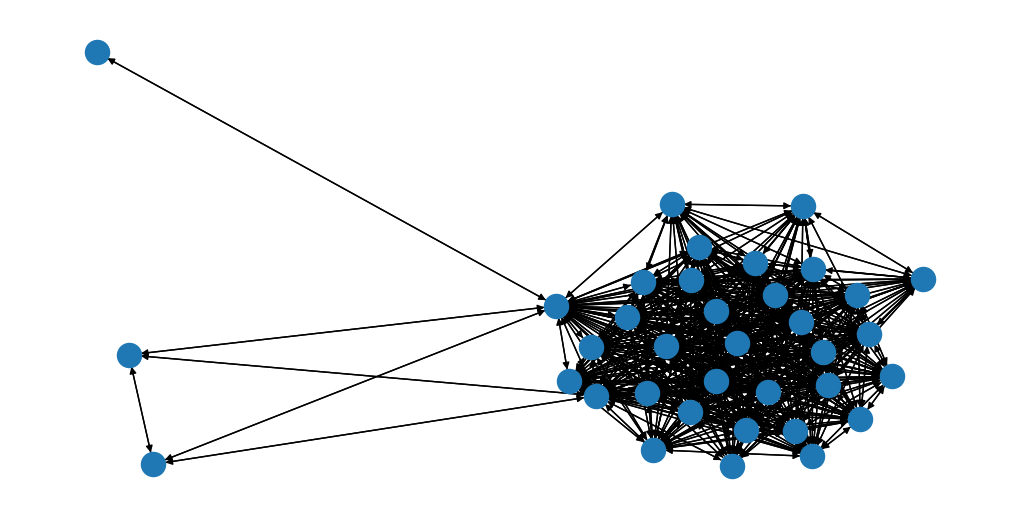

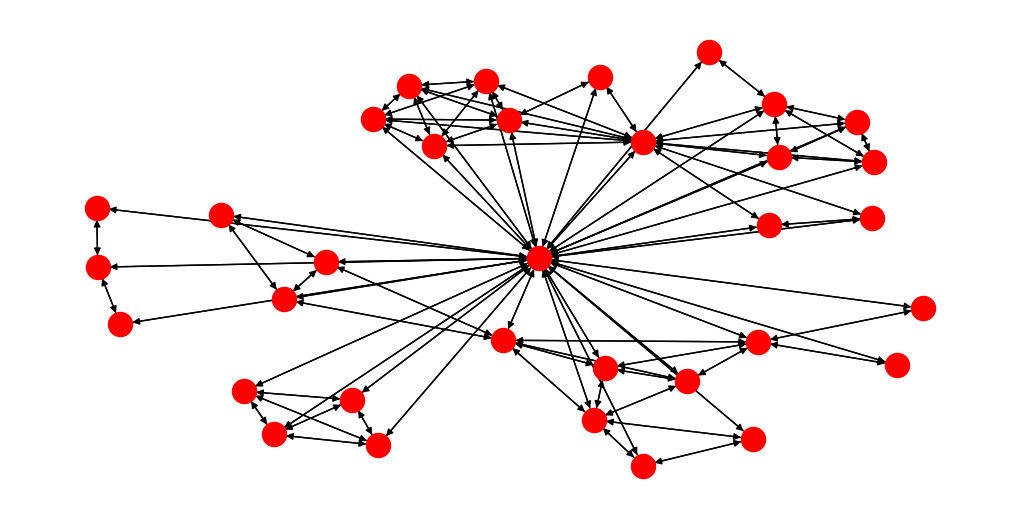

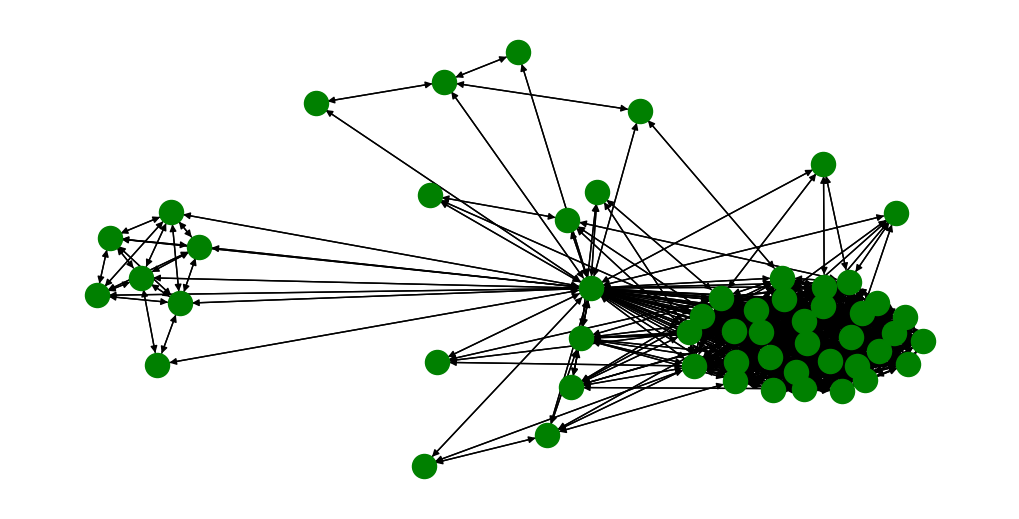

In [ ]:
data = random.choice([t for t in dataset if t.y==0])
g = to_networkx(data)
plt.figure(figsize=(10, 5))
nx.draw(g)
print(data.y)

data = random.choice([t for t in dataset if t.y==1])
g = to_networkx(data)
plt.figure(figsize=(10, 5))
nx.draw(g,node_color='r')
print(data.y)

data = random.choice([t for t in dataset if t.y==2])
g = to_networkx(data)
plt.figure(figsize=(10, 5))
nx.draw(g,node_color='g')
print(data.y)

Antes de comenzar con el entrenamiento y evaluación de los modelos conviene mencionar que se han detectado algunos problemas en el código proporcionado para la práctica y se han solucionado de las siguientes formas:

- Cálculo Aislado del Espectro Laplaciano (Graph-by-Graph):

    - Problema: Calcular el Laplaciano sobre el batch completo genera un grafo enorme, con tantas componentes desconectadas como moléculas haya en el lote. Matemáticamente, esto produce un autovalor igual a cero por cada componente. Al seleccionar los $k$ primeros, estos ceros acaparan la selección, entregando a la red autovectores vacíos que hacen inútil la geometría espacial y disparan el coste computacional al operar sobre una matriz gigante.

    - Solución implementada: Se ha aplicado una estrategia de "divide y vencerás", modificando la función para que desempaquete el lote y calcule el Laplaciano molécula por molécula de forma estrictamente individual. Esto garantiza un único autovalor cero por grafo, permitiendo que el resto de los $k$ autovectores extraigan correctamente las auténticas frecuencias estructurales y formas tridimensionales, reduciendo además la complejidad computacional.

- Corrección del Bucle de Validación (DataLoaders y Reproducibilidad):

    - Problema: La evaluación de modelos (incluyendo la red base Net) estaba consumiendo DataLoaders instanciados globalmente al inicio del notebook. Esto provocaba que, aunque los modelos variaran sus pesos iniciales y por tanto sí daban resultados distintos, no se estaba respetando la semilla de reproducibilidad para la partición de datos en las distintas iteraciones.

    - Solución implementada: Se ha reestructurado el bucle principal de evaluación. Ahora, la división del dataset y la generación de los train_loader y test_loader se ejecutan internamente en cada iteración, garantizando que los datos de entrenamiento y prueba cambien respetando la partición de los datos según la semilla activa.

Funciones heredadas con las modificaciones aplicadas:

In [5]:
def compute_laplacian_eigenvectors_pytorch(data, k):
    # 1. Convert PyTorch Geometric graph to NetworkX graph
    g = to_networkx(data, to_undirected=True)

    # 2. Compute the normalized Laplacian matrix using NetworkX
    # networkx.normalized_laplacian_matrix returns a sparse matrix
    # Then we make it dense and compatible with numpy
    L = nx.normalized_laplacian_matrix(g).todense()

    # 3. Finding eigen values and eigen vectors
    e, evecs = np.linalg.eig(L)
    #e.shape, evecs.shape

    # 4. Sort eigenvectors
    # Sort them (both e's and evecs's) ascending
    idx =e.argsort()
    e = e[idx]
    evecs = evecs[:,idx]

    # 3. Convert the sparse Laplacian matrix to a dense PyTorch tensor
    # Convert to dense numpy array first, then to torch tensor
    evecs_torch = torch.tensor(np.real(evecs[:,:k]), dtype=torch.float32)

    return evecs_torch

# Train and test functions. Use k=0 when no spectral info
def train(model, train_loader, optimizer, k):
    model.train()
    total_loss = 0
    total_correct = 0
    total_samples = 0

    for data in train_loader:  # Iterate in batches over the training dataset.
        optimizer.zero_grad()
        # Ensure all data components are on the correct device
        data.x = data.x.to(device)
        data.edge_index = data.edge_index.to(device)
        data.y = data.y.to(device)
        data.batch = data.batch.to(device)

        # Pass data components to the model
        out = model(data.x, data.edge_index, data.batch)

        loss = criterion(out, data.y)  # Compute the loss.
        loss.backward()  # Derive gradients.
        optimizer.step()  # Update parameters based on gradients.

        total_loss += loss.item() * data.y.size(0)
        pred = out.argmax(dim=1)
        total_correct += (pred == data.y).sum().item()
        total_samples += data.y.size(0)

    return total_loss / total_samples, total_correct / total_samples

def test(model, loader, k):
    model.eval()
    total_correct = 0
    total_samples = 0
    total_loss = 0

    with torch.no_grad():
        for data in loader:  # Iterate in batches over the training/test dataset.
            # Ensure all data components are on the correct device
            data.x = data.x.to(device)
            data.edge_index = data.edge_index.to(device)
            data.y = data.y.to(device)
            data.batch = data.batch.to(device)

            out = model(data.x, data.edge_index, data.batch)

            loss = criterion(out, data.y) # Compute the loss.
            total_loss += loss.item() * data.y.size(0)

            pred = out.argmax(dim=1)  # Use the class with highest probability.
            total_correct += int((pred == data.y).sum())  # Check against ground-truth labels.
            total_samples += data.y.size(0)

    return total_loss / total_samples, total_correct / total_samples

def split(dataset, seed):
  torch.manual_seed(seed)

  # Get 25% approx per test
  split_idx = int(len(dataset) * 0.75)
  print("split idx", split_idx)

  train_dataset = dataset[:split_idx]
  test_dataset = dataset[split_idx:]

  #print(f'Number of training graphs: {len(train_dataset)}')
  #print(f'Number of test graphs: {len(test_dataset)}')
  return train_dataset, test_dataset

Debido a la cantidad de grafos y su tamaño sacamos fuera el cálculo de los autovectores, que es más eficiente computacionalmente y así agilizamos el cálculo.

In [ ]:
class AñadirAutovectores(object):
    def __init__(self, k):
        self.k = k

    def __call__(self, data):
        if self.k > 0:
            # calculamos los autovectores usando la función
            evecs = compute_laplacian_eigenvectors_pytorch(data, self.k)

            # rellenamos con ceros si hay menos de k autovectores
            num_evecs = evecs.size(1)
            if num_evecs < self.k:
                columnas_faltantes = self.k - num_evecs
                evecs = F.pad(evecs, (0, columnas_faltantes, 0, 0), "constant", 0.0)

            # lo concatenamos con las características que ya tenga el grafo
            if data.x is not None:
                data.x = torch.cat([data.x, evecs], dim=1)
            else:
                data.x = evecs

        return data

Calculamos el dataset con la transformación para k=4. Debemos aplicar la misma técnica que anteriormente para el dataset original. Se carga el conjunto de datos, se realiza la transformación con el PE y entonces se hace el mismo undersampling que anteriormente. Después cargamos en colab este conjunto de datos con los autovectores calculados desde google drive.

In [ ]:
transformacion_k = T.Compose([
    T.LocalDegreeProfile(),
    AñadirAutovectores(k=4)
])

# se calculan los autovectores y se le concatenan directamente
dataset_k = TUDataset(root='data/TUDataset', name='COLLAB', pre_transform=transformacion_k, force_reload=True)

Processing...
Done!


In [ ]:
indices_clase_0 = [] # Alta Energía (2600 grafos)
indices_clase_1 = [] # Materia Condensada (1625 grafos)
indices_clase_2 = [] # Astrofísica (775 grafos)

for i, data in enumerate(dataset_k):
    if data.y.item() == 0:
        indices_clase_0.append(i)
    elif data.y.item() == 1:
        indices_clase_1.append(i)
    elif data.y.item() == 2:
        indices_clase_2.append(i)

# muestrear aleatoriamente 775 grafos de cada clase (con semilla para reproducibilidad)
random.seed(12345)
muestras_por_clase = 775

indices_0_sub = random.sample(indices_clase_0, muestras_por_clase)
indices_1_sub = random.sample(indices_clase_1, muestras_por_clase)
indices_2_sub = random.sample(indices_clase_2, muestras_por_clase) # Coge todos los de la clase 2

# unir todos los índices y desordenarlos para que no queden agrupados por clase
indices_finales = indices_0_sub + indices_1_sub + indices_2_sub
random.shuffle(indices_finales)

# crear la lista final de grafos
dataset_balanceado_k4 = [dataset_k[i] for i in indices_finales]

print(f"Total de grafos: {len(dataset_balanceado_k4)}")

# comprobación de que está perfectamente balanceado
clases_finales = [data.y.item() for data in dataset_balanceado_k4]
print(f"Distribución final -> Clase 0: {clases_finales.count(0)}, Clase 1: {clases_finales.count(1)}, Clase 2: {clases_finales.count(2)}")

# GUARDAR EL DATASET
nombre_archivo = 'COLLAB_balanceado_2325_k4.pt'
torch.save(dataset_balanceado_k4, nombre_archivo)
print(f"\nDataset guardado en el archivo: {nombre_archivo}")

Total de grafos: 2325
Distribución final -> Clase 0: 775, Clase 1: 775, Clase 2: 775

Dataset guardado en el archivo: COLLAB_balanceado_2325_k4.pt


In [ ]:
print("Descargando el dataset...")
!gdown --id 145DJy-J3FHWdF6WRN7Djvo-Qe-f8Eh65 -O COLLAB_balanceado_2325_k4.pt

dataset_k = torch.load('/content/COLLAB_balanceado_2325_k4.pt', weights_only=False)
print(f"Cargados {len(dataset)} grafos desde disco.")

Descargando el dataset...
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=145DJy-J3FHWdF6WRN7Djvo-Qe-f8Eh65
From (redirected): https://drive.google.com/uc?id=145DJy-J3FHWdF6WRN7Djvo-Qe-f8Eh65&confirm=t&uuid=8f94c8ff-fd2f-44a8-9e0c-dc06ad752b0c
To: /content/COLLAB_balanceado_2325_k4.pt
100% 407M/407M [00:03<00:00, 128MB/s]
Cargados 2325 grafos desde disco.


## Experimento 1: Evaluación de Arquitecturas Base

Iniciamos el análisis del dataset **COLLAB** estableciendo nuestras líneas base.
Se utiliza la configuración estándar predeterminada, adaptada a la naturaleza de este conjunto:

| Hiperparámetro | Valor |
| :--- | :--- |
| Canales Ocultos (*Hidden Channels*) | 64 |
| Número de Capas Convolucionales | 3 |
| Resolución Espectral ($k$) | 4 |
| Tipo de Agregación (*Pooling*) | Global Mean Pool |

Las redes se adaptan a la entrada sintética y a la salida de 3 clases:

* **GCN (Línea base):** Su capa inicial recibe **5 dimensiones** (*Local Degree Profile*). Tras 3 capas de 64 canales, emite la predicción sobre las 3 clases, ignorando la topología espacial.
* **GCNEig (Fusión temprana):** Amplía la entrada a **9 dimensiones** (5 sintéticas + 4 espaciales). Procesa simultáneamente las estadísticas de coautoría y la posición global del investigador.
* **GCNEigDecoupled (Fusión tardía):** Procesa las 5 estadísticas locales en la rama convolucional y proyecta los 4 autovectores geométricos en una capa lineal independiente (a 32 canales). Ambas vías se concatenan al final de la red (`conv3`) para la clasificación.

In [ ]:
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels, seed):
        super(GCN, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(5, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, 3)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCN(hidden_channels=64,seed=12345)
print(model)

class GCNEig(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEig, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(5 + k, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, 3)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEig(hidden_channels=64, seed=12345, k=4)
print(model)

class GCNEigDecoupled(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEigDecoupled, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(5, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, 3)
        self.lin2 = Linear(k, hidden_channels // 2)
        self.k = k # Store k for use in forward

    def forward(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = 5 # Get the original number of node features
        # Assuming the input x has original features first, then PE
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)


        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier (This comment is from the original notebook, it should be 4.)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = 5 # Get the original number of node features
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)

        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEigDecoupled(hidden_channels=64, seed=12345, k=4)
print(model)

GCN(
  (conv1): GCNConv(5, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=3, bias=True)
)
GCNEig(
  (conv1): GCNConv(9, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=3, bias=True)
)
GCNEigDecoupled(
  (conv1): GCNConv(5, 64)
  (conv2): GCNConv(64, 32)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=3, bias=True)
  (lin2): Linear(in_features=4, out_features=32, bias=True)
)


In [ ]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 64
k_val = 4

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
POOLING_TYPE = 'Global Mean Pool'
NUM_LAYERS = 3

# Here you can add models to train and test (include your own models)
models = [GCN, GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):
  ExperimentResult = []
  best_model = None
  current_model_class = models[j]

  print(f"Training Model: {current_model_class.__name__}")

  # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
  # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

  if j == 0:
      data = dataset
  elif j > 0:
      data = dataset_k

  for i in range(10):
      print("Random State", RandList[i]," in the iteration",i)
      current_seed = RandList[i]

      train_dataset, test_dataset = split(data, current_seed)
      train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
      test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

      # Instantiate model based on its class and its required arguments
      if current_model_class == GCN:
          model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
          k_for_laplacian = 0 # GCN does not use PE
      elif current_model_class == GCNEig:
          model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
          k_for_laplacian = k_val
      elif current_model_class == GCNEigDecoupled:
          model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
          k_for_laplacian = k_val
      elif current_model_class == Net: # Net model uses in_channels, out_channels directly
          model = current_model_class(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)
          k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                              # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

      optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
      for epoch in range(1, 101):
          # The `train` function now receives the model object directly
          loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
          print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

      # The `test` function also receives the model object directly
      test_loss, acc = test(model, test_loader, k=k_for_laplacian)
      print('Test Accuracy: {:.5f}'.format(acc))

      # Save the best model over the 10 runs
      if best_model is None or acc > best_model[1]:
          best_model = [model, acc]
      ExperimentResult.append(acc)

      file_exists = os.path.isfile("resultados_REDDIT_BINARY.csv")
      with open("resultados_REDDIT_BINARY.csv", mode='a', newline='', encoding='utf-8') as f:
          writer = csv.writer(f)
          if not file_exists:
              # Escribimos las cabeceras solo la primera vez que se crea el archivo
              writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])

          # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
          acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
          acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
          # Escribimos los datos específicos de esta única ejecución
          writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


  mean_acc = np.mean(ExperimentResult) * 100
  std_acc = np.std(ExperimentResult) * 100

  mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
  std_formatted = f"{std_acc:.2f}".replace('.', ',')

  with open("resultados_REDDIT_BINARY.csv", mode='a', newline='', encoding='utf-8') as f:
      writer = csv.writer(f)
      # Escribimos la línea de resumen. Las precisiones individuales van vacías.
      writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

  print(current_model_class.__name__) # Name of the model
  print('{} +- {}'.format(mean_acc, std_acc))
  global_results.append(ExperimentResult.copy())
  global_best_models.append(best_model.copy())

cuda
Training Model: GCN
Random State 12345  in the iteration 0
split idx 1743
Epoch: 001, Loss: 1.52960, Train Acc: 0.53471
Epoch: 002, Loss: 0.77530, Train Acc: 0.62020
Epoch: 003, Loss: 0.70942, Train Acc: 0.68560
Epoch: 004, Loss: 0.66803, Train Acc: 0.70683
Epoch: 005, Loss: 0.65900, Train Acc: 0.70625
Epoch: 006, Loss: 0.64799, Train Acc: 0.71486
Epoch: 007, Loss: 0.64447, Train Acc: 0.70855
Epoch: 008, Loss: 0.63380, Train Acc: 0.72002
Epoch: 009, Loss: 0.64531, Train Acc: 0.70625
Epoch: 010, Loss: 0.62472, Train Acc: 0.72920
Epoch: 011, Loss: 0.61315, Train Acc: 0.72748
Epoch: 012, Loss: 0.63438, Train Acc: 0.72461
Epoch: 013, Loss: 0.63646, Train Acc: 0.71601
Epoch: 014, Loss: 0.63559, Train Acc: 0.71773
Epoch: 015, Loss: 0.62649, Train Acc: 0.73150
Epoch: 016, Loss: 0.60924, Train Acc: 0.73781
Epoch: 017, Loss: 0.60809, Train Acc: 0.73379
Epoch: 018, Loss: 0.64479, Train Acc: 0.71830
Epoch: 019, Loss: 0.61661, Train Acc: 0.72806
Epoch: 020, Loss: 0.61226, Train Acc: 0.72633
E

Las métricas obtenidas tras la evaluación base se detallan a continuación:

| Modelo | Hidden Dim. | Num. Layers | Pooling | $k$ | Train Acc. $\pm$ Std (%) | Test Acc. $\pm$ Std (%) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **GCN** | 64 | 3 | Mean | 0 | 74.11 $\pm$ 1.16 | 73.95 $\pm$ 0.84 |
| **GCNEig** | 64 | 3 | Mean | 4 | 72.94 $\pm$ 1.47 | **73.98 $\pm$ 0.83** |
| **GCNEigDecoupled**| 64 | 3 | Mean | 4 | 73.76 $\pm$ 1.14 | 73.37 $\pm$ 1.11 |

El hallazgo más positivo de este primer experimento es la ausencia de *overfitting*. Las precisiones de entrenamiento y validación están alineadas, evidenciando un aprendizaje robusto (en el caso de `GCNEig`, la validación incluso supera ligeramente al entrenamiento).

En cuanto a la comparativa, los tres modelos muestran un rendimiento muy parejo (en torno al ~74%):

La fusión temprana (`GCNEig`) logra una ligera ventaja (73.98%) frente a la línea base `GCN` (73.95%) y la `GCNEigDecoupled` cede terreno (73.37%). En esta configuración inicial, aportar información geométrica ($k=4$) no supone todavía una ventaja diferencial clara frente a la línea base.

En la coautoría científica, los subcampos pueden identificarse por la presencia de investigadores destacados o por el volumen total de grupos de investigación. Para detectar estas estructuras específicas, el **Experimento 2** evaluará las agregaciones **`Global Max Pool`** y **`Global Add Pool`**.

## Experimento 2: Impacto de `Max Pool` y `Add Pool`

Pensamos que el promedio (`Mean Pool`) puede diluir la información. En este experimento modificamos la capa de agregación (*readout layer*) planteando dos nuevas hipótesis:

* **`Global Max Pool`:** Evaluamos si aislar la activación más alta (identificar a los investigadores principales) mejora el rendimiento.
* **`Global Add Pool`:** Comprobamos si la clasificación del subcampo de la física está relacionada directamente de la magnitud y el volumen total del equipo de investigación.

In [ ]:
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels, seed):
        super(GCN, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(5, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, 3)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCN(hidden_channels=64,seed=12345)
print(model)

class GCNEig(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEig, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(5 + k, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, 3)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEig(hidden_channels=64, seed=12345, k=4)
print(model)

class GCNEigDecoupled(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEigDecoupled, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(5, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, 3)
        self.lin2 = Linear(k, hidden_channels // 2)
        self.k = k # Store k for use in forward

    def forward(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = 5 # Get the original number of node features
        # Assuming the input x has original features first, then PE
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)


        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier (This comment is from the original notebook, it should be 4.)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = 5 # Get the original number of node features
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)

        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEigDecoupled(hidden_channels=64, seed=12345, k=4)
print(model)

GCN(
  (conv1): GCNConv(5, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=3, bias=True)
)
GCNEig(
  (conv1): GCNConv(9, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=3, bias=True)
)
GCNEigDecoupled(
  (conv1): GCNConv(5, 64)
  (conv2): GCNConv(64, 32)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=3, bias=True)
  (lin2): Linear(in_features=4, out_features=32, bias=True)
)


In [ ]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 64
k_val = 4

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
POOLING_TYPE = 'Global Max Pool'
NUM_LAYERS = 3

# Here you can add models to train and test (include your own models)
models = [GCN, GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):
    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    if j == 0:
        data = dataset
    elif j > 0:
        data = dataset_k

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(data, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=5, out_channels=3, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_COLLAB.csv")
        with open("resultados_COLLAB.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])

            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_COLLAB.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cuda
Training Model: GCN
Random State 12345  in the iteration 0
split idx 1743


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch: 001, Loss: 1.53494, Train Acc: 0.52438
Epoch: 002, Loss: 0.75671, Train Acc: 0.63396
Epoch: 003, Loss: 0.68344, Train Acc: 0.70224
Epoch: 004, Loss: 0.69918, Train Acc: 0.68560
Epoch: 005, Loss: 0.65324, Train Acc: 0.70855
Epoch: 006, Loss: 0.64688, Train Acc: 0.70912
Epoch: 007, Loss: 0.62672, Train Acc: 0.73953
Epoch: 008, Loss: 0.64245, Train Acc: 0.72002
Epoch: 009, Loss: 0.64445, Train Acc: 0.71142
Epoch: 010, Loss: 0.62591, Train Acc: 0.72920
Epoch: 011, Loss: 0.61880, Train Acc: 0.72232
Epoch: 012, Loss: 0.65057, Train Acc: 0.71658
Epoch: 013, Loss: 0.65070, Train Acc: 0.70338
Epoch: 014, Loss: 0.64739, Train Acc: 0.72232
Epoch: 015, Loss: 0.62428, Train Acc: 0.71715
Epoch: 016, Loss: 0.60973, Train Acc: 0.74928
Epoch: 017, Loss: 0.59259, Train Acc: 0.74584
Epoch: 018, Loss: 0.62358, Train Acc: 0.72347
Epoch: 019, Loss: 0.60050, Train Acc: 0.74068
Epoch: 020, Loss: 0.62039, Train Acc: 0.72002
Epoch: 021, Loss: 0.60627, Train Acc: 0.73609
Epoch: 022, Loss: 0.60600, Train A

In [ ]:
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels, seed):
        super(GCN, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(5, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, 3)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_add_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_add_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCN(hidden_channels=64,seed=12345)
print(model)

class GCNEig(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEig, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(5 + k, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, 3)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_add_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_add_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEig(hidden_channels=64, seed=12345, k=4)
print(model)

class GCNEigDecoupled(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEigDecoupled, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(5, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, 3)
        self.lin2 = Linear(k, hidden_channels // 2)
        self.k = k # Store k for use in forward

    def forward(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = 5 # Get the original number of node features
        # Assuming the input x has original features first, then PE
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)


        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_add_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier (This comment is from the original notebook, it should be 4.)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = 5 # Get the original number of node features
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)

        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_add_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEigDecoupled(hidden_channels=64, seed=12345, k=4)
print(model)

GCN(
  (conv1): GCNConv(5, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=3, bias=True)
)
GCNEig(
  (conv1): GCNConv(9, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=3, bias=True)
)
GCNEigDecoupled(
  (conv1): GCNConv(5, 64)
  (conv2): GCNConv(64, 32)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=3, bias=True)
  (lin2): Linear(in_features=4, out_features=32, bias=True)
)


In [ ]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 64
k_val = 4

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
POOLING_TYPE = 'Global Add Pool'
NUM_LAYERS = 3

# Here you can add models to train and test (include your own models)
models = [GCN, GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):
    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    if j == 0:
        data = dataset
    elif j > 0:
        data = dataset_k

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(data, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=5, out_channels=3, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_COLLAB.csv")
        with open("resultados_COLLAB.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])

            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_COLLAB.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cuda
Training Model: GCN
Random State 12345  in the iteration 0
split idx 1743
Epoch: 001, Loss: 148.49917, Train Acc: 0.51004
Epoch: 002, Loss: 3.59850, Train Acc: 0.57028
Epoch: 003, Loss: 1.58558, Train Acc: 0.57143
Epoch: 004, Loss: 1.21396, Train Acc: 0.50660
Epoch: 005, Loss: 1.23359, Train Acc: 0.51004
Epoch: 006, Loss: 1.19116, Train Acc: 0.36374
Epoch: 007, Loss: 1.09050, Train Acc: 0.39472
Epoch: 008, Loss: 1.08219, Train Acc: 0.41480
Epoch: 009, Loss: 1.07372, Train Acc: 0.40906
Epoch: 010, Loss: 1.06583, Train Acc: 0.42513
Epoch: 011, Loss: 1.08054, Train Acc: 0.42456
Epoch: 012, Loss: 1.08589, Train Acc: 0.41021
Epoch: 013, Loss: 1.08878, Train Acc: 0.40562
Epoch: 014, Loss: 1.08125, Train Acc: 0.41251
Epoch: 015, Loss: 1.10097, Train Acc: 0.41538
Epoch: 016, Loss: 1.08405, Train Acc: 0.40734
Epoch: 017, Loss: 1.08082, Train Acc: 0.41251
Epoch: 018, Loss: 1.06502, Train Acc: 0.43603
Epoch: 019, Loss: 1.07410, Train Acc: 0.42685
Epoch: 020, Loss: 1.08332, Train Acc: 0.41939

Las métricas obtenidas tras evaluar ambas configuraciones de agregación se detallan a continuación:

| Modelo | Hidden Dim. | Num. Layers | Pooling | k | Train Acc. ± Std (%) | Test Acc. ± Std (%) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **Global Max Pool** | | | | | | |
| **GCN** | 64 | 3 | Max | 0 | 74.55 ± 1.11 | 73.54 ± 1.60 |
| **GCNEig** | 64 | 3 | Max | 4 | 74.71 ± 0.52 | **74.79 ± 1.32** |
| **GCNEigDec.** | 64 | 3 | Max | 4 | 74.25 ± 1.04 | 74.21 ± 1.03 |
| **Global Add Pool** | | | | | | |
| **GCN** | 64 | 3 | Add | 0 | 59.21 ± 14.38 | 61.72 ± 11.98 |
| **GCNEig** | 64 | 3 | Add | 4 | 51.64 ± 13.15 | 53.87 ± 11.81 |
| **GCNEigDec.** | 64 | 3 | Add | 4 | 67.72 ± 6.23 | 66.37 ± 5.35 |

La variación de esta capa transforma por completo el comportamiento de las redes:

* **El Fracaso de `Add Pool`:** El rendimiento se desploma al 50-60% y la inestabilidad se dispara (desviaciones > 11%). Sumar las características confunde al modelo, confirmando que el volumen total del equipo no es un factor válido para discriminar el subcampo científico.
* **El éxito de `Max Pool`:** Extraer las activaciones máximas (probablemente identificando a los investigadores principales) mejora los resultados. Destaca la fusión temprana (`GCNEig`), que alcanza nuestra nueva mejor marca con un **74.79%** en validación, manteniendo un aprendizaje sano y sin *overfitting*.

La ausencia continua de *overfitting* sugiere que el estancamiento en torno al 75% se debe a un límite en la capacidad de representación.

Esto motiva el **Experimento 3**, donde ajustaremos los canales ocultos (*hidden channels*):
1. **128 canales:** Para comprobar si dotar a la red de mayor memoria le permite descifrar patrones de colaboración más complejos.
2. **32 canales:** Para descartar sobre-parametrización dada la simplicidad de la entrada (5 variables locales).

Para estas pruebas, cada arquitectura mantendrá su mejor capa de agregación: `Mean Pool` para `GCN`, y `Max Pool` para `GCNEig` y `GCNEigDecoupled`.

## Experimento 3: Ajuste de *Hidden Channels*

Para intentar superar el rendimiento actual, evaluaremos el impacto de variar la capacidad latente de la red probando con **32 y 128 canales ocultos**.

A partir de este punto, cada modelo utilizará exclusivamente la capa de agregación (*readout layer*) que mejores resultados le ha dado:
* **GCN:** `Mean Pool`
* **GCNEig y GCNEigDecoupled:** `Max Pool`

Dado que en COLLAB hemos logrado un aprendizaje robusto y sin *overfitting* a partir de una entrada muy simple (apenas 5 variables estadísticas locales), nos planteamos dos escenarios opuestos:

* **Prueba de Compresión (32 canales):** Proyectar 5 características directamente sobre 64 canales podría suponer una sobre-parametrización innecesaria. Reducir el espacio latente nos permitirá comprobar si un modelo más comprimido y eficiente es capaz de mantener o mejorar el rendimiento.
* **Prueba de Expansión (128 canales):** Por el contrario, aumentar la memoria estructural busca explorar si una mayor capacidad latente permite a la red descifrar patrones de colaboración científica mucho más complejos.

In [ ]:
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels, seed):
        super(GCN, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(5, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, 3)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCN(hidden_channels=32,seed=12345)
print(model)

class GCNEig(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEig, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(5 + k, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, 3)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEig(hidden_channels=32, seed=12345, k=4)
print(model)

class GCNEigDecoupled(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEigDecoupled, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(5, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, 3)
        self.lin2 = Linear(k, hidden_channels // 2)
        self.k = k # Store k for use in forward

    def forward(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = 5 # Get the original number of node features
        # Assuming the input x has original features first, then PE
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)


        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier (This comment is from the original notebook, it should be 4.)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = 5 # Get the original number of node features
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)

        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEigDecoupled(hidden_channels=32, seed=12345, k=4)
print(model)

GCN(
  (conv1): GCNConv(5, 32)
  (conv2): GCNConv(32, 32)
  (conv3): GCNConv(32, 32)
  (lin): Linear(in_features=32, out_features=3, bias=True)
)
GCNEig(
  (conv1): GCNConv(9, 32)
  (conv2): GCNConv(32, 32)
  (conv3): GCNConv(32, 32)
  (lin): Linear(in_features=32, out_features=3, bias=True)
)
GCNEigDecoupled(
  (conv1): GCNConv(5, 32)
  (conv2): GCNConv(32, 16)
  (conv3): GCNConv(32, 32)
  (lin): Linear(in_features=32, out_features=3, bias=True)
  (lin2): Linear(in_features=4, out_features=16, bias=True)
)


In [ ]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 32
k_val = 4

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
NUM_LAYERS = 3

# Here you can add models to train and test (include your own models)
models = [GCN, GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):

    if j == 0:
        POOLING_TYPE = 'Global Mean Pool'
    elif j == 1:
        POOLING_TYPE = 'Global Max Pool'
    elif j == 2:
        POOLING_TYPE = 'Global Max Pool'

    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    if j == 0:
      data = dataset
    elif j > 0:
      data = dataset_k

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(data, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=5, out_channels=3, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_COLLAB.csv")
        with open("resultados_COLLAB.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])

            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_COLLAB.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cuda
Training Model: GCN
Random State 12345  in the iteration 0
split idx 1743
Epoch: 001, Loss: 1.45386, Train Acc: 0.53528
Epoch: 002, Loss: 0.76541, Train Acc: 0.64200
Epoch: 003, Loss: 0.70925, Train Acc: 0.68330
Epoch: 004, Loss: 0.67499, Train Acc: 0.70453
Epoch: 005, Loss: 0.65690, Train Acc: 0.71371
Epoch: 006, Loss: 0.64463, Train Acc: 0.72461
Epoch: 007, Loss: 0.65351, Train Acc: 0.71371
Epoch: 008, Loss: 0.64076, Train Acc: 0.72289
Epoch: 009, Loss: 0.64275, Train Acc: 0.71830
Epoch: 010, Loss: 0.65376, Train Acc: 0.70683
Epoch: 011, Loss: 0.66626, Train Acc: 0.71715
Epoch: 012, Loss: 0.62981, Train Acc: 0.72691
Epoch: 013, Loss: 0.63201, Train Acc: 0.71486
Epoch: 014, Loss: 0.61908, Train Acc: 0.73494
Epoch: 015, Loss: 0.65491, Train Acc: 0.70338
Epoch: 016, Loss: 0.62850, Train Acc: 0.72633
Epoch: 017, Loss: 0.63809, Train Acc: 0.71715
Epoch: 018, Loss: 0.63495, Train Acc: 0.72691
Epoch: 019, Loss: 0.62691, Train Acc: 0.71888
Epoch: 020, Loss: 0.61945, Train Acc: 0.71486
E

In [ ]:
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels, seed):
        super(GCN, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(5, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, 3)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCN(hidden_channels=128,seed=12345)
print(model)

class GCNEig(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEig, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(5 + k, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, 3)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEig(hidden_channels=128, seed=12345, k=4)
print(model)

class GCNEigDecoupled(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEigDecoupled, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(5, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, 3)
        self.lin2 = Linear(k, hidden_channels // 2)
        self.k = k # Store k for use in forward

    def forward(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = 5 # Get the original number of node features
        # Assuming the input x has original features first, then PE
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)


        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier (This comment is from the original notebook, it should be 4.)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = 5 # Get the original number of node features
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)

        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEigDecoupled(hidden_channels=128, seed=12345, k=4)
print(model)

GCN(
  (conv1): GCNConv(5, 128)
  (conv2): GCNConv(128, 128)
  (conv3): GCNConv(128, 128)
  (lin): Linear(in_features=128, out_features=3, bias=True)
)
GCNEig(
  (conv1): GCNConv(9, 128)
  (conv2): GCNConv(128, 128)
  (conv3): GCNConv(128, 128)
  (lin): Linear(in_features=128, out_features=3, bias=True)
)
GCNEigDecoupled(
  (conv1): GCNConv(5, 128)
  (conv2): GCNConv(128, 64)
  (conv3): GCNConv(128, 128)
  (lin): Linear(in_features=128, out_features=3, bias=True)
  (lin2): Linear(in_features=4, out_features=64, bias=True)
)


In [ ]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 128
k_val = 4

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
NUM_LAYERS = 3

# Here you can add models to train and test (include your own models)
models = [GCN, GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):

    if j == 0:
        POOLING_TYPE = 'Global Mean Pool'
    elif j == 1:
        POOLING_TYPE = 'Global Max Pool'
    elif j == 2:
        POOLING_TYPE = 'Global Max Pool'

    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    if j == 0:
      data = dataset
    elif j > 0:
      data = dataset_k

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(data, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=5, out_channels=3, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_COLLAB.csv")
        with open("resultados_COLLAB.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])

            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_COLLAB.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cuda
Training Model: GCN
Random State 12345  in the iteration 0
split idx 1743
Epoch: 001, Loss: 1.95251, Train Acc: 0.54102
Epoch: 002, Loss: 0.72374, Train Acc: 0.67757
Epoch: 003, Loss: 0.66742, Train Acc: 0.71256
Epoch: 004, Loss: 0.64492, Train Acc: 0.71543
Epoch: 005, Loss: 0.65860, Train Acc: 0.70511
Epoch: 006, Loss: 0.67627, Train Acc: 0.69707
Epoch: 007, Loss: 0.65472, Train Acc: 0.70970
Epoch: 008, Loss: 0.66221, Train Acc: 0.70453
Epoch: 009, Loss: 0.62823, Train Acc: 0.72404
Epoch: 010, Loss: 0.66351, Train Acc: 0.71027
Epoch: 011, Loss: 0.66577, Train Acc: 0.71314
Epoch: 012, Loss: 0.63554, Train Acc: 0.72002
Epoch: 013, Loss: 0.62302, Train Acc: 0.73379
Epoch: 014, Loss: 0.63543, Train Acc: 0.73035
Epoch: 015, Loss: 0.62043, Train Acc: 0.73723
Epoch: 016, Loss: 0.62288, Train Acc: 0.73666
Epoch: 017, Loss: 0.62587, Train Acc: 0.73723
Epoch: 018, Loss: 0.62607, Train Acc: 0.72691
Epoch: 019, Loss: 0.62332, Train Acc: 0.73207
Epoch: 020, Loss: 0.63737, Train Acc: 0.72174
E

Las métricas obtenidas tras evaluar 32 y 128 canales ocultos se detallan a continuación:

| Modelo | Hidden Dim. | Num. Layers | Pooling | k | Train Acc. ± Std (%) | Test Acc. ± Std (%) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **Configuración: 32 canales** | | | | | | |
| **GCN** | 32 | 3 | Mean | 0 | 73.82 ± 0.62 | 73.85 ± 1.18 |
| **GCNEig** | 32 | 3 | Max | 4 | 74.28 ± 0.52 | **74.85 ± 1.03** |
| **GCNEigDec.** | 32 | 3 | Max | 4 | 73.81 ± 1.02 | 74.62 ± 0.95 |
| **Configuración: 128 canales** | | | | | | |
| **GCN** | 128 | 3 | Mean | 0 | 73.76 ± 0.71 | 73.38 ± 0.98 |
| **GCNEig** | 128 | 3 | Max | 4 | 74.24 ± 0.73 | 74.38 ± 1.31 |
| **GCNEigDec.** | 128 | 3 | Max | 4 | 73.86 ± 0.83 | 73.38 ± 1.46 |

* **El Fracaso de la Expansión (128 canales):** Aumentar la capacidad no aporta soluciones e incluso empeora ligeramente las predicciones frente a los 64 canales.
* **El Éxito de la Compresión (32 canales):** Reducir la capacidad resulta ser una estrategia buena. Los modelos espectrales alcanzan sus mejores marcas: `GCNEig` lidera con **74.85%** en validación, seguido por `GCNEigDecoupled` (74.62%). Mantienen una estabilidad altísima ($\sim \pm 1.0\%$) y las precisiones de *Train* y *Test* siguen perfectamente alineadas.

A la vista de estos resultados, consolidamos los **32 canales ocultos** como el nuevo estándar para los modelos geométricos.

Dado que seguimos teniendo un aprendizaje muy sano (sin memorización, llegando la validación a superar al entrenamiento), la hipótesis es que la red aún tiene margen para aprender patrones estructurales más profundos.

Por ello, el **Experimento 4** evaluará el impacto de la profundidad arquitectónica, **aumentando a 4 capas convolucionales**.

## Experimento 4: Profundidad de la Red (*Num. Layers*)

Procedemos a evaluar el impacto de la profundidad arquitectónica añadiendo una **cuarta capa convolucional**. Para esta prueba, se mantienen estrictamente las configuraciones óptimas descubiertas hasta la fecha:
* **GCN (Línea base):** 64 canales y `Mean Pool`.
* **GCNEig y GCNEigDecoupled:** 32 canales, `Max Pool` y $k=4$.

En COLLAB analizamos redes de colaboración científica con un tamaño moderado (media de ~72 nodos) pero con una **altísima densidad** (el grado medio roza las 44 aristas por nodo).

Al tener un grafo tan denso, utilizar 3 capas implica que la información ya se propaga por casi toda la red en muy pocos saltos. Aumentar a 4 capas tiene como objetivo expandir este campo receptor para comprobar si una mayor propagación del mensaje permite a la red asimilar patrones más profundos.

In [ ]:
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels, seed):
        super(GCN, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(5, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.conv4 = GCNConv(hidden_channels, hidden_channels) # NUEVA CAPA
        self.lin = Linear(hidden_channels, 3)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        x = x.relu() # NUEVA ACTIVACIÓN
        x = self.conv4(x, edge_index) # NUEVA CAPA

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        x = x.relu()
        x = self.conv4(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCN(hidden_channels=64,seed=12345)
print(model)


class GCNEig(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEig, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(5 + k, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.conv4 = GCNConv(hidden_channels, hidden_channels) # NUEVA CAPA
        self.lin = Linear(hidden_channels, 3)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        x = x.relu() # NUEVA ACTIVACIÓN
        x = self.conv4(x, edge_index) # NUEVA CAPA

        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        x = x.relu()
        x = self.conv4(x, edge_index)

        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEig(hidden_channels=32, seed=12345, k=4)
print(model)


class GCNEigDecoupled(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEigDecoupled, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(5, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.conv4 = GCNConv(hidden_channels, hidden_channels) # NUEVA CAPA
        self.lin = Linear(hidden_channels, 3)
        self.lin2 = Linear(k, hidden_channels // 2)
        self.k = k # Store k for use in forward

    def forward(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = 5 # Get the original number of node features

        # Assuming the input x has original features first, then PE
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)
        x = x.relu() # NUEVA ACTIVACIÓN
        x = self.conv4(x, edge_index) # NUEVA CAPA

        # 3. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 4. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)
        x = x.relu()
        x = self.conv4(x, edge_index)

        # 3. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEigDecoupled(hidden_channels=32, seed=12345, k=4)
print(model)

GCN(
  (conv1): GCNConv(5, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (conv4): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=3, bias=True)
)
GCNEig(
  (conv1): GCNConv(9, 32)
  (conv2): GCNConv(32, 32)
  (conv3): GCNConv(32, 32)
  (conv4): GCNConv(32, 32)
  (lin): Linear(in_features=32, out_features=3, bias=True)
)
GCNEigDecoupled(
  (conv1): GCNConv(5, 32)
  (conv2): GCNConv(32, 16)
  (conv3): GCNConv(32, 32)
  (conv4): GCNConv(32, 32)
  (lin): Linear(in_features=32, out_features=3, bias=True)
  (lin2): Linear(in_features=4, out_features=16, bias=True)
)


In [ ]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
k_val = 4

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
NUM_LAYERS = 4

# Here you can add models to train and test (include your own models)
models = [GCN, GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):

    if j == 0:
        POOLING_TYPE = 'Global Mean Pool'
        hidden_channels_val = 64
    elif j == 1:
        POOLING_TYPE = 'Global Max Pool'
        hidden_channels_val = 32
    elif j == 2:
        POOLING_TYPE = 'Global Max Pool'
        hidden_channels_val = 32

    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    if j == 0:
      data = dataset
    elif j > 0:
      data = dataset_k

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(data, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=5, out_channels=3, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_COLLAB.csv")
        with open("resultados_COLLAB.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])

            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_COLLAB.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cuda
Training Model: GCN
Random State 12345  in the iteration 0
split idx 1743
Epoch: 001, Loss: 1.18604, Train Acc: 0.52438
Epoch: 002, Loss: 0.75324, Train Acc: 0.64773
Epoch: 003, Loss: 0.67640, Train Acc: 0.69134
Epoch: 004, Loss: 0.67137, Train Acc: 0.70052
Epoch: 005, Loss: 0.63631, Train Acc: 0.72519
Epoch: 006, Loss: 0.68511, Train Acc: 0.69306
Epoch: 007, Loss: 0.65250, Train Acc: 0.71543
Epoch: 008, Loss: 0.63378, Train Acc: 0.71945
Epoch: 009, Loss: 0.62121, Train Acc: 0.73723
Epoch: 010, Loss: 0.63233, Train Acc: 0.72806
Epoch: 011, Loss: 0.63413, Train Acc: 0.72519
Epoch: 012, Loss: 0.67101, Train Acc: 0.68445
Epoch: 013, Loss: 0.64272, Train Acc: 0.70797
Epoch: 014, Loss: 0.63996, Train Acc: 0.72519
Epoch: 015, Loss: 0.63416, Train Acc: 0.71256
Epoch: 016, Loss: 0.62250, Train Acc: 0.72978
Epoch: 017, Loss: 0.61224, Train Acc: 0.73035
Epoch: 018, Loss: 0.62451, Train Acc: 0.70912
Epoch: 019, Loss: 0.62897, Train Acc: 0.71429
Epoch: 020, Loss: 0.62829, Train Acc: 0.72461
E

/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch: 001, Loss: 1.12615, Train Acc: 0.51463
Epoch: 002, Loss: 0.73623, Train Acc: 0.66839
Epoch: 003, Loss: 0.69879, Train Acc: 0.69076
Epoch: 004, Loss: 0.67085, Train Acc: 0.69421
Epoch: 005, Loss: 0.67740, Train Acc: 0.69306
Epoch: 006, Loss: 0.64593, Train Acc: 0.72289
Epoch: 007, Loss: 0.66465, Train Acc: 0.69937
Epoch: 008, Loss: 0.66857, Train Acc: 0.70166
Epoch: 009, Loss: 0.61978, Train Acc: 0.73207
Epoch: 010, Loss: 0.67164, Train Acc: 0.69650
Epoch: 011, Loss: 0.63136, Train Acc: 0.73092
Epoch: 012, Loss: 0.63059, Train Acc: 0.73781
Epoch: 013, Loss: 0.63398, Train Acc: 0.73666
Epoch: 014, Loss: 0.62449, Train Acc: 0.72691
Epoch: 015, Loss: 0.60516, Train Acc: 0.73264
Epoch: 016, Loss: 0.62803, Train Acc: 0.71715
Epoch: 017, Loss: 0.61552, Train Acc: 0.72863
Epoch: 018, Loss: 0.63218, Train Acc: 0.72576
Epoch: 019, Loss: 0.61734, Train Acc: 0.73035
Epoch: 020, Loss: 0.61814, Train Acc: 0.73035
Epoch: 021, Loss: 0.61641, Train Acc: 0.72978
Epoch: 022, Loss: 0.61779, Train A

Las métricas obtenidas tras aumentar la arquitectura a 4 capas son las siguientes:

| Modelo | Hidden Dim. | Num. Layers | Pooling | $k$ | Train Acc. $\pm$ Std (%) | Test Acc. $\pm$ Std (%) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **GCN** | 64 | 4 | Mean | 0 | 73.73 $\pm$ 0.60 | 74.07 $\pm$ 1.36 |
| **GCNEig** | 32 | 4 | Max | 4 | 74.09 $\pm$ 0.97 | 74.26 $\pm$ 0.96 |
| **GCNEigDec.** | 32 | 4 | Max | 4 | 73.41 $\pm$ 1.04 | **75.21 $\pm$ 0.88** |

El aumento de profundidad genera impactos muy dispares según la arquitectura:

* **Ruptura del 75%:** `GCNEigDecoupled` es el claro ganador, logrando un excelente **75.21%** en validación con una varianza mínima ($\pm 0.88$).
* **Dilución de la señal:** `GCNEig` sufre un ligero retroceso frente a sus marcas con 3 capas. Al propagar la geometría desde el inicio durante 4 saltos en grafos tan densos, la señal topológica acaba diluyéndose.
* **Estancamiento de la línea base:** `GCN` se mantiene estable (~74.07%). Esto confirma que, sin información geométrica, aumentar las capas no aporta nueva capacidad discriminativa.

A la vista de estos resultados, consolidamos las configuraciones óptimas para la fase final:

* **Estructuras de 3 capas:** `GCN` (64 canales) y `GCNEig` (32 canales).
* **Estructuras de 4 capas:** `GCNEigDecoupled` (32 canales).

El **Experimento 5** se centrará en optimizar la entrada geométrica. Variaremos el número de autovectores del Laplaciano ($k \in \{6, 8, 10\}$) para comprobar si proporcionar una mayor resolución espacial ayuda a exprimir aún más la capacidad predictiva en redes de colaboración tan densas.

## Experimento 5: Resolución Espacial (*Positional Encoding*, $k$)

Para finalizar la fase de experimentación con COLLAB, y habiendo fijado las configuraciones óptimas descubiertas en los pasos anteriores (32 canales ocultos y `Global Max Pool` para ambas arquitecturas espectrales, con 3 capas para `GCNEig` y 4 capas para `GCNEigDecoupled`), procedemos a evaluar el impacto de la resolución espacial geométrica.

Se incrementará progresivamente el número de autovectores del Laplaciano ($k \in \{6, 8, 10\}$) para comprobar si proporcionar una descripción topológica más detallada ayuda a la red a clasificar con mayor precisión.

Dado que tratamos con redes de colaboración científica muy densas (con un grado medio cercano a las 44 aristas por nodo), una resolución básica de $k=4$ proporciona una visión global de la comunidad. 

Incrementar el parámetro a $k=6$, $8$ y $10$ añade en la red una información espacial de mayor detalle. El objetivo es comprobar si este nivel de detalle permite a los modelos romper su techo de rendimiento actual (estancado en el entorno del 75%).

In [ ]:
transformacion_k = T.Compose([
    T.LocalDegreeProfile(),
    AñadirAutovectores(k=6)
])

# se calculan los autovectores y se le concatenan directamente
dataset_k = TUDataset(root='data/TUDataset', name='COLLAB', pre_transform=transformacion_k, force_reload=True)

Processing...
Done!


In [ ]:
indices_clase_0 = [] # Alta Energía (2600 grafos)
indices_clase_1 = [] # Materia Condensada (1625 grafos)
indices_clase_2 = [] # Astrofísica (775 grafos)

for i, data in enumerate(dataset_k):
    if data.y.item() == 0:
        indices_clase_0.append(i)
    elif data.y.item() == 1:
        indices_clase_1.append(i)
    elif data.y.item() == 2:
        indices_clase_2.append(i)

# muestrear aleatoriamente 775 grafos de cada clase (con semilla para reproducibilidad)
random.seed(12345)
muestras_por_clase = 775

indices_0_sub = random.sample(indices_clase_0, muestras_por_clase)
indices_1_sub = random.sample(indices_clase_1, muestras_por_clase)
indices_2_sub = random.sample(indices_clase_2, muestras_por_clase) # Coge todos los de la clase 2

# unir todos los índices y desordenarlos para que no queden agrupados por clase
indices_finales = indices_0_sub + indices_1_sub + indices_2_sub
random.shuffle(indices_finales)

# crear la lista final de grafos
dataset_balanceado_k6 = [dataset_k[i] for i in indices_finales]

print(f"Total de grafos: {len(dataset_balanceado_k6)}")

# comprobación de que está perfectamente balanceado
clases_finales = [data.y.item() for data in dataset_balanceado_k6]
print(f"Distribución final -> Clase 0: {clases_finales.count(0)}, Clase 1: {clases_finales.count(1)}, Clase 2: {clases_finales.count(2)}")

# GUARDAR EL DATASET
nombre_archivo = 'COLLAB_balanceado_2325_k6.pt'
torch.save(dataset_balanceado_k6, nombre_archivo)
print(f"\nDataset guardado en el archivo: {nombre_archivo}")

Total de grafos: 2325
Distribución final -> Clase 0: 775, Clase 1: 775, Clase 2: 775

Dataset guardado en el archivo: COLLAB_balanceado_2325_k6.pt


In [ ]:
print("Descargando el dataset...")
!gdown --id 1SWwBwRmz4dk32V5gXGN1-3vpMN1IyXZI -O COLLAB_balanceado_2325_k6.pt

dataset_k = torch.load('/content/COLLAB_balanceado_2325_k6.pt', weights_only=False)
print(f"Cargados {len(dataset)} grafos desde disco.")

Descargando el dataset...
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1SWwBwRmz4dk32V5gXGN1-3vpMN1IyXZI
From (redirected): https://drive.google.com/uc?id=1SWwBwRmz4dk32V5gXGN1-3vpMN1IyXZI&confirm=t&uuid=bdf2aa1e-6a82-4a10-8b00-14f59236006d
To: /content/COLLAB_balanceado_2325_k6.pt
100% 410M/410M [00:03<00:00, 114MB/s]
Cargados 2325 grafos desde disco.


In [ ]:
class GCNEig(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEig, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(5 + k, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, 3)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEig(hidden_channels=32, seed=12345, k=6)
print(model)

class GCNEigDecoupled(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEigDecoupled, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(5, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.conv4 = GCNConv(hidden_channels, hidden_channels) # NUEVA CAPA
        self.lin = Linear(hidden_channels, 3)
        self.lin2 = Linear(k, hidden_channels // 2)
        self.k = k # Store k for use in forward

    def forward(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = 5 # Get the original number of node features

        # Assuming the input x has original features first, then PE
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)
        x = x.relu() # NUEVA ACTIVACIÓN
        x = self.conv4(x, edge_index) # NUEVA CAPA

        # 3. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 4. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)
        x = x.relu()
        x = self.conv4(x, edge_index)

        # 3. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEigDecoupled(hidden_channels=32, seed=12345, k=6)
print(model)

GCNEig(
  (conv1): GCNConv(11, 32)
  (conv2): GCNConv(32, 32)
  (conv3): GCNConv(32, 32)
  (lin): Linear(in_features=32, out_features=3, bias=True)
)
GCNEigDecoupled(
  (conv1): GCNConv(5, 32)
  (conv2): GCNConv(32, 16)
  (conv3): GCNConv(32, 32)
  (conv4): GCNConv(32, 32)
  (lin): Linear(in_features=32, out_features=3, bias=True)
  (lin2): Linear(in_features=6, out_features=16, bias=True)
)


#### *k = 6*

In [ ]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 32
k_val = 6

# Here you can add models to train and test (include your own models)
models = [GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

data = dataset_k

for j in range(len(models)):
    if j == 0:
        POOLING_TYPE = 'Global Max Pool'
        NUM_LAYERS = 3
    elif j == 1:
        POOLING_TYPE = 'Global Max Pool'
        NUM_LAYERS = 4

    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(data, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=data.num_features, out_channels=data.num_classes, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_COLLAB.csv")
        with open("resultados_COLLAB.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])

            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_COLLAB.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cuda
Training Model: GCNEig
Random State 12345  in the iteration 0
split idx 1743
Epoch: 001, Loss: 1.69168, Train Acc: 0.50029
Epoch: 002, Loss: 0.76423, Train Acc: 0.64200
Epoch: 003, Loss: 0.72778, Train Acc: 0.65806
Epoch: 004, Loss: 0.69000, Train Acc: 0.68732
Epoch: 005, Loss: 0.67466, Train Acc: 0.70797
Epoch: 006, Loss: 0.64316, Train Acc: 0.71256
Epoch: 007, Loss: 0.63154, Train Acc: 0.72174
Epoch: 008, Loss: 0.64484, Train Acc: 0.70797
Epoch: 009, Loss: 0.63975, Train Acc: 0.72633
Epoch: 010, Loss: 0.64654, Train Acc: 0.70912
Epoch: 011, Loss: 0.63874, Train Acc: 0.72978
Epoch: 012, Loss: 0.62949, Train Acc: 0.71888
Epoch: 013, Loss: 0.61672, Train Acc: 0.73264
Epoch: 014, Loss: 0.62629, Train Acc: 0.72060
Epoch: 015, Loss: 0.64074, Train Acc: 0.71945
Epoch: 016, Loss: 0.63317, Train Acc: 0.72117
Epoch: 017, Loss: 0.61558, Train Acc: 0.73723
Epoch: 018, Loss: 0.60915, Train Acc: 0.73092
Epoch: 019, Loss: 0.62137, Train Acc: 0.72691
Epoch: 020, Loss: 0.62451, Train Acc: 0.7188

#### *k = 8*

In [ ]:
transformacion_k = T.Compose([
    T.LocalDegreeProfile(),
    AñadirAutovectores(k=8)
])

# se calculan los autovectores y se le concatenan directamente
dataset_k = TUDataset(root='data/TUDataset', name='COLLAB', pre_transform=transformacion_k, force_reload=True)

Processing...
Done!


In [ ]:
indices_clase_0 = [] # Alta Energía (2600 grafos)
indices_clase_1 = [] # Materia Condensada (1625 grafos)
indices_clase_2 = [] # Astrofísica (775 grafos)

for i, data in enumerate(dataset_k):
    if data.y.item() == 0:
        indices_clase_0.append(i)
    elif data.y.item() == 1:
        indices_clase_1.append(i)
    elif data.y.item() == 2:
        indices_clase_2.append(i)

# muestrear aleatoriamente 775 grafos de cada clase (con semilla para reproducibilidad)
random.seed(12345)
muestras_por_clase = 775

indices_0_sub = random.sample(indices_clase_0, muestras_por_clase)
indices_1_sub = random.sample(indices_clase_1, muestras_por_clase)
indices_2_sub = random.sample(indices_clase_2, muestras_por_clase) # Coge todos los de la clase 2

# unir todos los índices y desordenarlos para que no queden agrupados por clase
indices_finales = indices_0_sub + indices_1_sub + indices_2_sub
random.shuffle(indices_finales)

# crear la lista final de grafos
dataset_balanceado_k8 = [dataset_k[i] for i in indices_finales]

print(f"Total de grafos: {len(dataset_balanceado_k8)}")

# comprobación de que está perfectamente balanceado
clases_finales = [data.y.item() for data in dataset_balanceado_k8]
print(f"Distribución final -> Clase 0: {clases_finales.count(0)}, Clase 1: {clases_finales.count(1)}, Clase 2: {clases_finales.count(2)}")

# GUARDAR EL DATASET
nombre_archivo = 'COLLAB_balanceado_2325_k8.pt'
torch.save(dataset_balanceado_k8, nombre_archivo)
print(f"\nDataset guardado en el archivo: {nombre_archivo}")

Total de grafos: 2325
Distribución final -> Clase 0: 775, Clase 1: 775, Clase 2: 775

Dataset guardado en el archivo: COLLAB_balanceado_2325_k8.pt


In [ ]:
print("Descargando el dataset...")
!gdown --id 1zyi6_piFTL1cBUWgwyD-wqZIt2kt3sb5 -O COLLAB_balanceado_2325_k8.pt

dataset_k = torch.load('/content/COLLAB_balanceado_2325_k8.pt', weights_only=False)
print(f"Cargados {len(dataset)} grafos desde disco.")

Descargando el dataset...
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1zyi6_piFTL1cBUWgwyD-wqZIt2kt3sb5
From (redirected): https://drive.google.com/uc?id=1zyi6_piFTL1cBUWgwyD-wqZIt2kt3sb5&confirm=t&uuid=d3d21992-407a-4e1d-93dd-b0449a91a360
To: /content/COLLAB_balanceado_2325_k8.pt
100% 413M/413M [00:07<00:00, 52.0MB/s]
Cargados 2325 grafos desde disco.


In [ ]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 32
k_val = 8

# Here you can add models to train and test (include your own models)
models = [GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

data = dataset_k

for j in range(len(models)):
    if j == 0:
        POOLING_TYPE = 'Global Max Pool'
        NUM_LAYERS = 3
    elif j == 1:
        POOLING_TYPE = 'Global Max Pool'
        NUM_LAYERS = 4

    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(data, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=data.num_features, out_channels=data.num_classes, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_COLLAB.csv")
        with open("resultados_COLLAB.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])

            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_COLLAB.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cuda
Training Model: GCNEig
Random State 12345  in the iteration 0
split idx 1743


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch: 001, Loss: 1.72012, Train Acc: 0.50258
Epoch: 002, Loss: 0.76837, Train Acc: 0.64601
Epoch: 003, Loss: 0.72599, Train Acc: 0.66036
Epoch: 004, Loss: 0.71210, Train Acc: 0.68904
Epoch: 005, Loss: 0.70127, Train Acc: 0.68101
Epoch: 006, Loss: 0.69074, Train Acc: 0.69880
Epoch: 007, Loss: 0.65560, Train Acc: 0.70740
Epoch: 008, Loss: 0.65197, Train Acc: 0.72347
Epoch: 009, Loss: 0.65126, Train Acc: 0.71830
Epoch: 010, Loss: 0.65063, Train Acc: 0.71830
Epoch: 011, Loss: 0.65464, Train Acc: 0.71371
Epoch: 012, Loss: 0.64681, Train Acc: 0.72519
Epoch: 013, Loss: 0.65889, Train Acc: 0.71429
Epoch: 014, Loss: 0.67014, Train Acc: 0.70453
Epoch: 015, Loss: 0.64445, Train Acc: 0.71658
Epoch: 016, Loss: 0.62985, Train Acc: 0.72232
Epoch: 017, Loss: 0.63970, Train Acc: 0.72289
Epoch: 018, Loss: 0.64187, Train Acc: 0.70970
Epoch: 019, Loss: 0.63066, Train Acc: 0.72347
Epoch: 020, Loss: 0.62986, Train Acc: 0.72633
Epoch: 021, Loss: 0.63724, Train Acc: 0.71945
Epoch: 022, Loss: 0.62306, Train A

#### *k = 10*

In [ ]:
transformacion_k = T.Compose([
    T.LocalDegreeProfile(),
    AñadirAutovectores(k=10)
])

# se calculan los autovectores y se le concatenan directamente
dataset_k = TUDataset(root='data/TUDataset', name='COLLAB', pre_transform=transformacion_k, force_reload=True)

Processing...
Done!


In [ ]:
indices_clase_0 = [] # Alta Energía (2600 grafos)
indices_clase_1 = [] # Materia Condensada (1625 grafos)
indices_clase_2 = [] # Astrofísica (775 grafos)

for i, data in enumerate(dataset_k):
    if data.y.item() == 0:
        indices_clase_0.append(i)
    elif data.y.item() == 1:
        indices_clase_1.append(i)
    elif data.y.item() == 2:
        indices_clase_2.append(i)

# muestrear aleatoriamente 775 grafos de cada clase (con semilla para reproducibilidad)
random.seed(12345)
muestras_por_clase = 775

indices_0_sub = random.sample(indices_clase_0, muestras_por_clase)
indices_1_sub = random.sample(indices_clase_1, muestras_por_clase)
indices_2_sub = random.sample(indices_clase_2, muestras_por_clase) # Coge todos los de la clase 2

# unir todos los índices y desordenarlos para que no queden agrupados por clase
indices_finales = indices_0_sub + indices_1_sub + indices_2_sub
random.shuffle(indices_finales)

# crear la lista final de grafos
dataset_balanceado_k10 = [dataset_k[i] for i in indices_finales]

print(f"Total de grafos: {len(dataset_balanceado_k10)}")

# comprobación de que está perfectamente balanceado
clases_finales = [data.y.item() for data in dataset_balanceado_k10]
print(f"Distribución final -> Clase 0: {clases_finales.count(0)}, Clase 1: {clases_finales.count(1)}, Clase 2: {clases_finales.count(2)}")

# GUARDAR EL DATASET
nombre_archivo = 'COLLAB_balanceado_2325_k10.pt'
torch.save(dataset_balanceado_k10, nombre_archivo)
print(f"\nDataset guardado en el archivo: {nombre_archivo}")

Total de grafos: 2325
Distribución final -> Clase 0: 775, Clase 1: 775, Clase 2: 775

Dataset guardado en el archivo: COLLAB_balanceado_2325_k10.pt


In [ ]:
print("Descargando el dataset...")
!gdown --id 16ZxpeLBuC9cnSP0dSIgx2MBYxBgFsmi8 -O COLLAB_balanceado_2325_k10.pt

dataset_k = torch.load('/content/COLLAB_balanceado_2325_k10.pt', weights_only=False)
print(f"Cargados {len(dataset)} grafos desde disco.")

Descargando el dataset...
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=16ZxpeLBuC9cnSP0dSIgx2MBYxBgFsmi8
From (redirected): https://drive.google.com/uc?id=16ZxpeLBuC9cnSP0dSIgx2MBYxBgFsmi8&confirm=t&uuid=eeebd78e-63c8-4deb-8004-099fb6c6fc6a
To: /content/COLLAB_balanceado_2325_k10.pt
100% 416M/416M [00:05<00:00, 76.8MB/s]
Cargados 2325 grafos desde disco.


In [ ]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 32
k_val = 10

# Here you can add models to train and test (include your own models)
models = [GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

data = dataset_k

for j in range(len(models)):
    if j == 0:
        POOLING_TYPE = 'Global Max Pool'
        NUM_LAYERS = 3
    elif j == 1:
        POOLING_TYPE = 'Global Max Pool'
        NUM_LAYERS = 4

    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(data, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=data.num_features, out_channels=data.num_classes, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_COLLAB.csv")
        with open("resultados_COLLAB.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])

            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_COLLAB.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cuda
Training Model: GCNEig
Random State 12345  in the iteration 0
split idx 1743
Epoch: 001, Loss: 1.39268, Train Acc: 0.51922
Epoch: 002, Loss: 0.78410, Train Acc: 0.63569
Epoch: 003, Loss: 0.71015, Train Acc: 0.67757
Epoch: 004, Loss: 0.69230, Train Acc: 0.68789
Epoch: 005, Loss: 0.66438, Train Acc: 0.71773
Epoch: 006, Loss: 0.63985, Train Acc: 0.72289
Epoch: 007, Loss: 0.64685, Train Acc: 0.71543
Epoch: 008, Loss: 0.63917, Train Acc: 0.72978
Epoch: 009, Loss: 0.64891, Train Acc: 0.71314
Epoch: 010, Loss: 0.65576, Train Acc: 0.71773
Epoch: 011, Loss: 0.64450, Train Acc: 0.72978
Epoch: 012, Loss: 0.62205, Train Acc: 0.73207
Epoch: 013, Loss: 0.61466, Train Acc: 0.72576
Epoch: 014, Loss: 0.62173, Train Acc: 0.72863
Epoch: 015, Loss: 0.63847, Train Acc: 0.72404
Epoch: 016, Loss: 0.61411, Train Acc: 0.73322
Epoch: 017, Loss: 0.64245, Train Acc: 0.72232
Epoch: 018, Loss: 0.62103, Train Acc: 0.72461
Epoch: 019, Loss: 0.61978, Train Acc: 0.72920
Epoch: 020, Loss: 0.61231, Train Acc: 0.7337

Las métricas obtenidas tras aumentar progresivamente el número de autovectores se detallan a continuación (se omite `GCN` al carecer de este parámetro):

| Modelo | Hidden Dim. | Num. Layers | Pooling | $k$ | Train Acc. $\pm$ Std (%) | Test Acc. $\pm$ Std (%) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **Resolución $k = 6$** | | | | | | |
| **GCNEig** | 32 | 3 | Max | 6 | 74.22 $\pm$ 1.12 | 74.50 $\pm$ 1.40 |
| **GCNEigDec.** | 32 | 4 | Max | 6 | 74.12 $\pm$ 0.82 | 73.92 $\pm$ 1.24 |
| **Resolución $k = 8$** | | | | | | |
| **GCNEig** | 32 | 3 | Max | 8 | 74.37 $\pm$ 1.00 | 74.62 $\pm$ 1.21 |
| **GCNEigDec.** | 32 | 4 | Max | 8 | 74.65 $\pm$ 0.80 | 74.47 $\pm$ 1.37 |
| **Resolución $k = 10$** | | | | | | |
| **GCNEig** | 32 | 3 | Max | 10 | 74.22 $\pm$ 1.44 | 74.64 $\pm$ 0.84 |
| **GCNEigDec.** | 32 | 4 | Max | 10 | 74.45 $\pm$ 0.83 | 74.67 $\pm$ 1.50 |

En COLLAB incrementar la información geométrica no se traduce en un mayor rendimiento, sino en un estancamiento:

* `GCNEig` fluctúa entre el 74.50% ($k=6$) y el 74.64% ($k=10$), sin lograr superar el **74.85%** que registró previamente con $k=4$. De forma similar, `GCNEigDecoupled` sufre un ligero retroceso y se recupera hasta el 74.67% ($k=10$), pero no alcanza su techo del **75.21%** ($k=4$).
* Pese a no mejorar, las redes demuestran gran solidez. Las precisiones de *Train* y *Test* siguen alineadas, demostrando que añadir más autovectores no provoca colapso por ruido ni sobreajuste.
* Esta estabilización muestra que los primeros 4 autovectores ($k=4$) contienen toda la información estructural (frecuencias bajas) necesaria para clasificar mejor. Las frecuencias más altas ($k \ge 6$) aportan detalles locales irrelevantes para la clasificación multiclase.

Seleccionamos como ganador absoluto al modelo **`GCNEigDecoupled` (32 canales, 4 capas, `Max Pool`, $k=4$)** por lograr el techo de rendimiento (**75.21%**). Le sigue muy de cerca `GCNEig` (32 canales, 3 capas, `Max Pool`, $k=4$), destacando por su gran eficiencia.

## Evaluación del modelo `Net`

Para concluir el análisis del *dataset* COLLAB, evaluamos una prueba del modelo de referencia `Net` (utilizando la semilla de reproducibilidad 12345). El objetivo de este ensayo es probar una arquitectura basada en agrupamiento jerárquico que, teóricamente, debería superar el rendimiento de los modelos convolucionales estándar.

Este modelo emplea `MinCut Pool`, una técnica avanzada de reducción de dimensionalidad espacial. Para esta evaluación final, la red se configuró de la siguiente manera:

* **Canales Ocultos (*Hidden Dim*):** 64
* **Número de Capas:** 2
* **Agregación (*Pooling*):** MinCut Pool
* **Resolución Espectral ($k$):** 10

In [6]:
class Net(torch.nn.Module):
    def __init__(self, in_channels, out_channels, hidden_channels=32):
        super(Net, self).__init__()

        # GCN Layer - MLP - Dense GCN Layer
        self.conv1 = GCNConv(in_channels, hidden_channels)
        num_of_centers =  10 # k
        # The degree of the node belonging to any of the centers
        self.pool1 = Linear(hidden_channels, num_of_centers)
        self.conv2 = DenseGraphConv(hidden_channels, hidden_channels)
        # MLPs towards out
        self.lin1 = Linear(hidden_channels, hidden_channels)
        self.lin2 = Linear(hidden_channels, out_channels)

        # Input: Batch of 20 graphs, each node F=3 features
        #        N1 + N2 + ... + N2 = 661
        # TSNE here?
    def forward(self, x, edge_index, batch):    # x torch.Size([661, 3]),  data.batch  torch.Size([661])
        # CONV1: Expand features from F=3 to F' = 32
        x = F.relu(self.conv1(x, edge_index))   # x torch.Size([661, 32])

        # Make all x_i of size N=MAX(N1,...,N20), e.g. N=40:
        x, mask = to_dense_batch(x, batch)      # x torch.Size([20, N, 32]) ; mask torch.Size([20, N]) batch_size=20
        #print("x size", x.size())

        # Make all adjacencies of size NxN
        adj = to_dense_adj(edge_index, batch)   # adj torch.Size([20, N, N])
        #print("adj_size", adj.size())

        # MLP of k=16 outputs s
        #print("adj_size", adj.size())
        s = self.pool1(x) # s torch.Size([20, N, k])
        #print("s_size", s.size())

        # MINCUT_POOL
        # Call to dense_cut_mincut_pool to get coarsened x, adj and the losses: k=16
        x, adj, mincut_loss, ortho_loss = dense_mincut_pool(x, adj, s, mask) # x torch.Size([20, 16, 32]),  adj torch.Size([20, 16, 16])
        #print("Coarsened x and adj sizes:", x.size(), adj.size())

        # CONV2: Now on coarsened x and adj:
        x = self.conv2(x, adj) #x torch.Size([20, 16, 32])
        #print("x_2 size", x.size())

        # Readout for each of the 20 graphs
        #x = x.mean(dim=1) # x torch.Size([20, 32])
        x = x.sum(dim=1) # x torch.Size([20, 32])
        #print("mean x_2 size", x.size())

        # Final MLP for graph classification: hidden channels = 32
        x = F.relu(self.lin1(x)) # x torch.Size([20, 32])
        #print("final x1 size", x.size())
        x = self.lin2(x) #x torch.Size([20, 2])
        #print("final x2 size", x.size())
        return F.log_softmax(x, dim=-1), mincut_loss , ortho_loss



In [7]:
def train_net(model, loader, optimizer, device):
    model.train()
    loss_all = 0
    correct = 0
    total_graphs = 0

    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()

        # El modelo Net devuelve 3 valores
        out, mc_loss, o_loss = model(data.x, data.edge_index, data.batch)

        # Sumamos las funciones de pérdida
        loss = F.nll_loss(out, data.y.view(-1)) + mc_loss + o_loss
        loss.backward()

        loss_all += data.y.size(0) * loss.item()
        optimizer.step()

        # Calculamos el accuracy de entrenamiento para el CSV
        pred = out.max(dim=1)[1]
        correct += pred.eq(data.y.view(-1)).sum().item()
        total_graphs += data.num_graphs

    return loss_all / total_graphs, correct / total_graphs

@torch.no_grad()
def test_net(model, loader, device):
    model.eval()
    loss_all = 0
    correct = 0
    total_graphs = 0

    for data in loader:
        data = data.to(device)
        out, mc_loss, o_loss = model(data.x, data.edge_index, data.batch)

        # Pérdida en test
        loss = F.nll_loss(out, data.y.view(-1)) + mc_loss + o_loss
        loss_all += data.y.size(0) * loss.item()

        # Accuracy en test
        pred = out.max(dim=1)[1]
        correct += pred.eq(data.y.view(-1)).sum().item()
        total_graphs += data.num_graphs

    return loss_all / total_graphs, correct / total_graphs

In [10]:
print("Training Model: Net (MinCut) - Single Run")

# Configuración específica para Net
current_seed = 12345  # Usamos solo la primera semilla
hidden_channels_val = 64
POOLING_TYPE = 'MinCut Pool'
NUM_LAYERS = 2
k_for_net = 10

train_dataset, test_dataset = split(dataset, current_seed)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

model = Net(in_channels=5, out_channels=3, hidden_channels=hidden_channels_val).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-4)

# como hacemos una unica run entrenamos 200 epochs
for epoch in range(1, 201):
    loss, acc_train = train_net(model, train_loader, optimizer, device)
    if epoch % 10 == 0 or epoch == 1: # imprimir cada 10 epochs
        print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

# evaluacion
test_loss, acc = test_net(model, test_loader, device)
print('Test Accuracy: {:.5f}'.format(acc))

# guardar resultados
file_exists = os.path.isfile("resultados_REDDIT_BINARY.csv")
with open("resultados_REDDIT_BINARY.csv", mode='a', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    if not file_exists:
        writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])

    acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
    acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')

    # Escribimos los datos de esta única ejecución (Iteración 0)
    writer.writerow(["Net", 0, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_net, acc_train_formatted, acc_test_formatted, "", ""])

    # Como solo hay 1 run, la media es el propio valor y la std es 0
    mean_formatted = acc_test_formatted
    std_formatted = "0,00"

    # Escribimos la línea de resumen
    writer.writerow(["Net", "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_net, "", "", mean_formatted, std_formatted])

Training Model: Net (MinCut) - Single Run
split idx 1743
Epoch: 001, Loss: 111.42063, Train Acc: 0.33678
Epoch: 010, Loss: 10.13356, Train Acc: 0.59610
Epoch: 020, Loss: 2.14593, Train Acc: 0.62077
Epoch: 030, Loss: 1.54408, Train Acc: 0.64314
Epoch: 040, Loss: 1.41956, Train Acc: 0.65462
Epoch: 050, Loss: 1.28701, Train Acc: 0.67585
Epoch: 060, Loss: 1.21998, Train Acc: 0.68330
Epoch: 070, Loss: 1.16581, Train Acc: 0.68503
Epoch: 080, Loss: 1.13012, Train Acc: 0.68388
Epoch: 090, Loss: 1.08274, Train Acc: 0.69248
Epoch: 100, Loss: 1.19153, Train Acc: 0.68675
Epoch: 110, Loss: 1.00192, Train Acc: 0.70625
Epoch: 120, Loss: 1.00164, Train Acc: 0.70683
Epoch: 130, Loss: 0.99183, Train Acc: 0.70281
Epoch: 140, Loss: 0.93551, Train Acc: 0.70396
Epoch: 150, Loss: 0.96121, Train Acc: 0.70281
Epoch: 160, Loss: 0.99915, Train Acc: 0.71256
Epoch: 170, Loss: 0.93053, Train Acc: 0.71888
Epoch: 180, Loss: 0.89231, Train Acc: 0.72691
Epoch: 190, Loss: 0.88117, Train Acc: 0.73092
Epoch: 200, Loss: 1.

Con la ejecución de este modelo se han obtenido las siguientes métricas:

| Modelo `Net` | Train Acc. (%) | Test Acc. (%) |
| :--- | :---: | :---: |
| **Configuración: 64 Canales** | 70.40 | 71.99 |

* A pesar de su mayor complejidad teórica, el modelo `Net` se queda a más de 3 puntos porcentuales de distancia de nuestra propia arquitectura **`GCNEigDecoupled`**, la cual alcanzó un **75.21%** (Experimento 4). Este contraste pone en valor el trabajo de optimización y diseño de nuestros modelos.
* Al intentar evaluar el modelo reduciendo su capacidad a 32 canales, se detectaron colapsos numéricos generados por divisores cercanos a cero, independientemente del ajuste en la *learning rate*. Esto demuestra que la técnica `MinCut Pool` resulta ser altamente inestable al enfrentarse a la topología de este conjunto de grafos.

### Análisis Visual del Espacio Latente (t-SNE)

Al tratarse de un problema de tres clases equitativamente balanceadas, el objetivo visual es la formación de tres clústeres bien definidos (correspondientes a cada subcampo de la física):

* **`GCN` (Izquierda):** Se observa una estructura solapada y caótica. Aunque se intuye un ligero agrupamiento, la gran mayoría de las muestras están mezcladas.
* **`GCNEig` (Centro):** Refleja un agrupamiento mucho más marcado (una clase a la izquierda, otra central, y otra a la derecha), aunque sin fronteras de decisión estrictas. Añadir los autovectores del Laplaciano permite a la red dotar de sentido a las topologías.
* **`GCNEigDecoupled` (Derecha):** Visualmente, no se aprecia una mejora radical frente al modelo de fusión temprana. Las tres clases parecen separadas en tres grandes grupos, pero siguen existiendo puntos mal situados y zonas de mezcladas sin una frontera limpia.

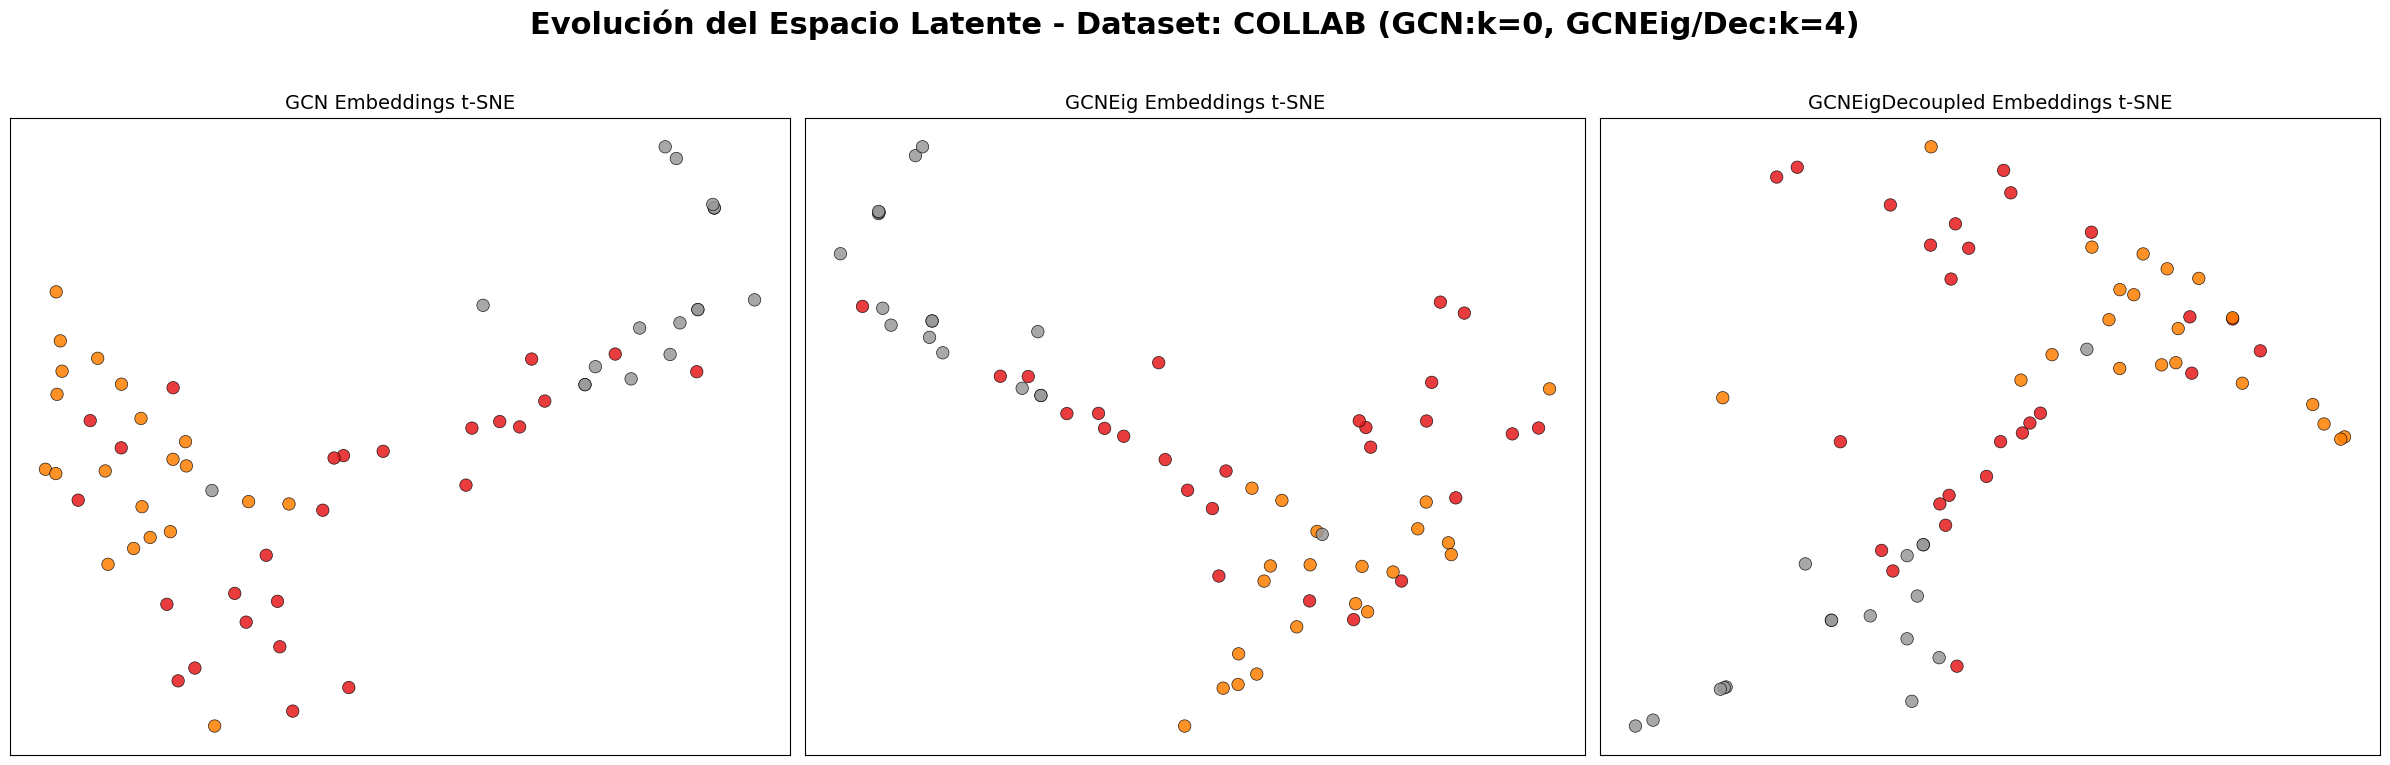

In [ ]:
data_for_viz_batch = next(iter(test_loader)).to(device)
num_orig_features = 5

# --- GCN Model (global_best_models[0][0]) ---
# This model was trained without Positional Encodings (k=0), so it expects 5 features.
best_gcn_model = global_best_models[0][0]
data_gcn_x = data_for_viz_batch.x[:, :num_orig_features] # Take only the original 5 features
out_gcn_embeddings = best_gcn_model.get_embeddings(data_gcn_x, data_for_viz_batch.edge_index, data_for_viz_batch.batch)

# --- Prepare data for GCNEig and GCNEigDecoupled (trained with k=4) ---
k_for_eig_models = 4 # These models were trained with k=4 in Experiment 4

evecs_list_k4 = []
for single_graph in data_for_viz_batch.to_data_list():
    evecs_single_k4 = compute_laplacian_eigenvectors_pytorch(single_graph, k=k_for_eig_models)
    # Pad with zeros if less than k_for_eig_models eigenvectors were found
    if evecs_single_k4.size(1) < k_for_eig_models:
        columnas_faltantes = k_for_eig_models - evecs_single_k4.size(1)
        evecs_single_k4 = F.pad(evecs_single_k4, (0, columnas_faltantes, 0, 0), "constant", 0.0)
    evecs_list_k4.append(evecs_single_k4)

# Concatenate eigenvectors for the entire batch, ensuring correct shape
evecs_for_eig_k4 = torch.cat(evecs_list_k4, dim=0).to(device)

# Create x with original 5 features + k=4 positional encodings
x_for_eig_k4 = torch.cat([data_for_viz_batch.x[:, :num_orig_features], evecs_for_eig_k4], dim=1)

# --- GCNEig Model (global_best_models[1][0]) ---
best_gcn_eig_model = global_best_models[1][0]
out_gcn_eig_embeddings = best_gcn_eig_model.get_embeddings(x_for_eig_k4, data_for_viz_batch.edge_index, data_for_viz_batch.batch)

# --- GCNEigDecoupled Model (global_best_models[2][0]) ---
best_gcn_eig_decoupled_model = global_best_models[2][0]
out_gcn_eig_decoupled_embeddings = best_gcn_eig_decoupled_model.get_embeddings(x_for_eig_k4, data_for_viz_batch.edge_index, data_for_viz_batch.batch)


# TSNE Transformation
tsne = TSNE(n_components=2, random_state=12345, init='pca', learning_rate='auto')

tsne_gcn = tsne.fit_transform(out_gcn_embeddings.detach().cpu().numpy())
tsne_gcn_eig = tsne.fit_transform(out_gcn_eig_embeddings.detach().cpu().numpy())
tsne_gcn_decoupled = tsne.fit_transform(out_gcn_eig_decoupled_embeddings.detach().cpu().numpy())

fig, axs = plt.subplots(1, 3, figsize=(24, 8))

# GCN
axs[0].set_title('GCN Embeddings t-SNE', fontsize=14)
scatter0 = axs[0].scatter(tsne_gcn[:,0], tsne_gcn[:,1], c=data_for_viz_batch.y.cpu(), cmap='Set1', s=80, alpha=0.85, edgecolors='black', linewidths=0.5)

# GCNEig
axs[1].set_title('GCNEig Embeddings t-SNE', fontsize=14)
axs[1].scatter(tsne_gcn_eig[:,0], tsne_gcn_eig[:,1], c=data_for_viz_batch.y.cpu(), cmap='Set1', s=80, alpha=0.85, edgecolors='black', linewidths=0.5)

# GCNEigDecoupled
axs[2].set_title('GCNEigDecoupled Embeddings t-SNE', fontsize=14)
axs[2].scatter(tsne_gcn_decoupled[:,0], tsne_gcn_decoupled[:,1], c=data_for_viz_batch.y.cpu(), cmap='Set1', s=80, alpha=0.85, edgecolors='black', linewidths=0.5)

for ax in axs:
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(f'Evolución del Espacio Latente - Dataset: COLLAB (GCN:k=0, GCNEig/Dec:k=4)', fontsize=22, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.show()

## Conclusiones y Comparación con la Tesis

Tras completar la fase de experimentación en el *dataset* COLLAB, a continuación se resumen los resultados principales.

| Modelo | Hidden Dim. | Num. Layers | Pooling | $k$ | Train Acc. $\pm$ Std (%) | Test Acc. $\pm$ Std (%) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **GCN** | 64 | 3 | Mean | 0 | 73.73 $\pm$ 0.60 | 74.07 $\pm$ 1.36 |
| **GCNEig** | 32 | 3 | Max | 4 | 74.28 $\pm$ 0.52 | 74.85 $\pm$ 1.03 |
| **GCNEigDec.** | 32 | 4 | Max | 4 | 73.41 $\pm$ 1.04 | **75.21 $\pm$ 0.88** |

* **GCN:** No logró mejorar con cambios de profundidad o anchura, por lo que se mantuvo su configuración inicial como la óptima.
* **Modelos espectrales:** Ambos encontraron una clara ventaja al comprimir su capacidad a 32 canales y utilizar `Global Max Pool` para identificar a los investigadores principales. Además, mientras `GCNEig` fue más eficiente con 3 capas, `GCNEigDecoupled` demostró una enorme resistencia al *oversmoothing*, beneficiándose de una 4ª capa para la clasificación. 
* **Resolución espectral:** La alta conectividad de estas redes hizo que los 4 primeros autovectores ($k=4$) contuvieran toda la información relevante; las frecuencias altas ($k \ge 6$) resultaron redundantes.

* El modelo **`GCNEigDecoupled` (32 canales, 4 capas, `Max Pool` y $k=4$)** domina en este conjunto, logrando una precisión en validación del **75.21%** y destacando por su gran estabilidad computacional ($\pm 0.88$). En la tesis de referencia se reporta un rendimiento del **77.50% $\pm$ 0.50** utilizando una arquitectura sofisticada (`GatedGCN`) combinada con una codificación posicional de caminos aleatorios (*Random Walk Positional Encoding - RWPE*). Aunque nuestro modelo se queda a 2.29 puntos porcentuales de dicha marca, los resultados son un éxito. Hemos superado la barrera del 75% empleando una base convolucional estándar (`GCNConv`), mucho más sencilla, ligera y rápida de entrenar que el mecanismo de puertas y atención paramétrica de una `GatedGCN`. Además, mientras que la arquitectura `Net` fracasó y colapsó numéricamente en el 71.99% debido a la extrema densidad de estos grafos, nuestra estrategia ha demostrado ser una solución robusta y eficiente para este problema.